In [1]:
import numpy as np
import pandas as pd
import torch
import joblib
import os
import itertools
from tqdm.notebook import tqdm
import math
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm

import torchvision
from torchvision import transforms
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score
from cmnist_train_new import ImageColorizerUNet, HLCellMeansShrunkVec

from matplotlib import pyplot as plt
from operations import Intervention

In [2]:
# Load the generated ColorMNIST data (Xia-encoder + z)
data_dir = 'data/cmnist_new'  # ← change if you used a different output_dir

import torch
import joblib

# -----------------------------
# Load intervention mapping
# -----------------------------
# omega: dict[label_str -> label_str], e.g. "obs", "D=6", "C=7", ...
omega        = torch.load(f'{data_dir}/intervention_mapping.pkl')
Ill_relevant = list(omega.keys())
Ihl_relevant = list(omega.values())

print("Interventions loaded:")
print("  Ill_relevant:", Ill_relevant)
print("  Ihl_relevant:", Ihl_relevant)

# -----------------------------
# Load LL / HL samples
# -----------------------------
# Dll_samples[label] = (imgs_01, shapes_norm, digits, colors)
#   imgs_01      : (N, 3, 32, 32) in [0,1]
#   shapes_norm  : (N, 1, 32, 32) in [-1,1]
#   digits,colors: (N,)
Dll_samples  = torch.load(f'{data_dir}/dll_samples.pkl')

# Dhl_samples[label] = (N, 20 + d_z)
#   cols 0..9   : one-hot Digit_
#   cols 10..19 : one-hot Color_
#   cols 20..   : z in R^{d_z}
Dhl_samples  = torch.load(f'{data_dir}/dhl_samples.pkl')

# Observational key is now the string "obs"
obs_key = "obs"
assert obs_key in Dll_samples, f"'obs' not found in Dll_samples keys: {Dll_samples.keys()}"
assert obs_key in Dhl_samples, f"'obs' not found in Dhl_samples keys: {Dhl_samples.keys()}"

# Infer latent dimension d_z from HL observational tensor
d_z = Dhl_samples[obs_key].shape[1] - 20

# -----------------------------
# Load low-level U-Net model
# -----------------------------
ll_model_state = torch.load(f'{data_dir}/ll_model_unet.pth', map_location="cpu")
ll_model       = ImageColorizerUNet()
ll_model.load_state_dict(ll_model_state)
ll_model.eval()

# Abduced low-level noise U_ll_hat (in tanh / [-1,1] space, shape (N, 3, 32, 32))
U_ll_hat = torch.load(f'{data_dir}/U_ll_hat.pkl')

# -----------------------------
# Load high-level cell-means model on z
# -----------------------------
# hl_model is HLCellMeansShrunkVec mapping (Xd, Xc) -> mean z in R^{d_z}
hl_model = joblib.load(f'{data_dir}/hl_model_cellmeans_z.joblib')

# Abduced high-level noise U_hl_hat in latent space z, shape (N, d_z)
U_hl_hat = torch.load(f'{data_dir}/U_hl_hat_z.pkl')

print("\nData & models loaded successfully!")
print(f"  - Observational LL images shape : {Dll_samples[obs_key][0].shape}   # imgs_01")
print(f"  - Observational LL shapes shape : {Dll_samples[obs_key][1].shape}   # shapes_norm")
print(f"  - Observational HL tensor shape : {Dhl_samples[obs_key].shape}      # 20 + d_z (d_z={d_z})")
print(f"  - Low-level noise U_ll_hat      : {U_ll_hat.shape}")
print(f"  - High-level noise U_hl_hat     : {U_hl_hat.shape}")

# Variable names (LL / HL)
D_LL, C_LL, P_LL = 'Digit', 'Color', 'Pixels'
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'  # I_HL now stands for the latent z block


Interventions loaded:
  Ill_relevant: ['obs', 'D=6', 'D=8', 'D=4', 'C=7', 'C=0', 'C=4', 'D=6,C=7', 'D=8,C=0', 'D=4,C=4']
  Ihl_relevant: ['obs', 'D=6', 'D=8', 'D=4', 'C=7', 'C=0', 'C=4', 'D=6,C=7', 'D=8,C=0', 'D=4,C=4']

Data & models loaded successfully!
  - Observational LL images shape : torch.Size([10000, 3, 32, 32])   # imgs_01
  - Observational LL shapes shape : torch.Size([10000, 1, 32, 32])   # shapes_norm
  - Observational HL tensor shape : torch.Size([10000, 84])      # 20 + d_z (d_z=64)
  - Low-level noise U_ll_hat      : torch.Size([10000, 3, 32, 32])
  - High-level noise U_hl_hat     : torch.Size([10000, 64])


=== U_ll_hat Analysis ===
Shape: torch.Size([10000, 3, 32, 32])
Data type: torch.float32
Min value: -0.637488
Max value: 0.699508
Mean value: 0.001224
Std value: 0.033575
Non-zero elements: 30719984/30720000 (100.00%)

=== U_hl_hat (z-noise) Analysis ===
Shape: torch.Size([10000, 64])
Data type: torch.float32
Latent dim d_z: 64
Min value (overall): -4.656994
Max value (overall): 5.912094
Mean value (overall): -0.000083
Std value (overall): 0.727605
Non-zero elements: 640000/640000 (100.00%)


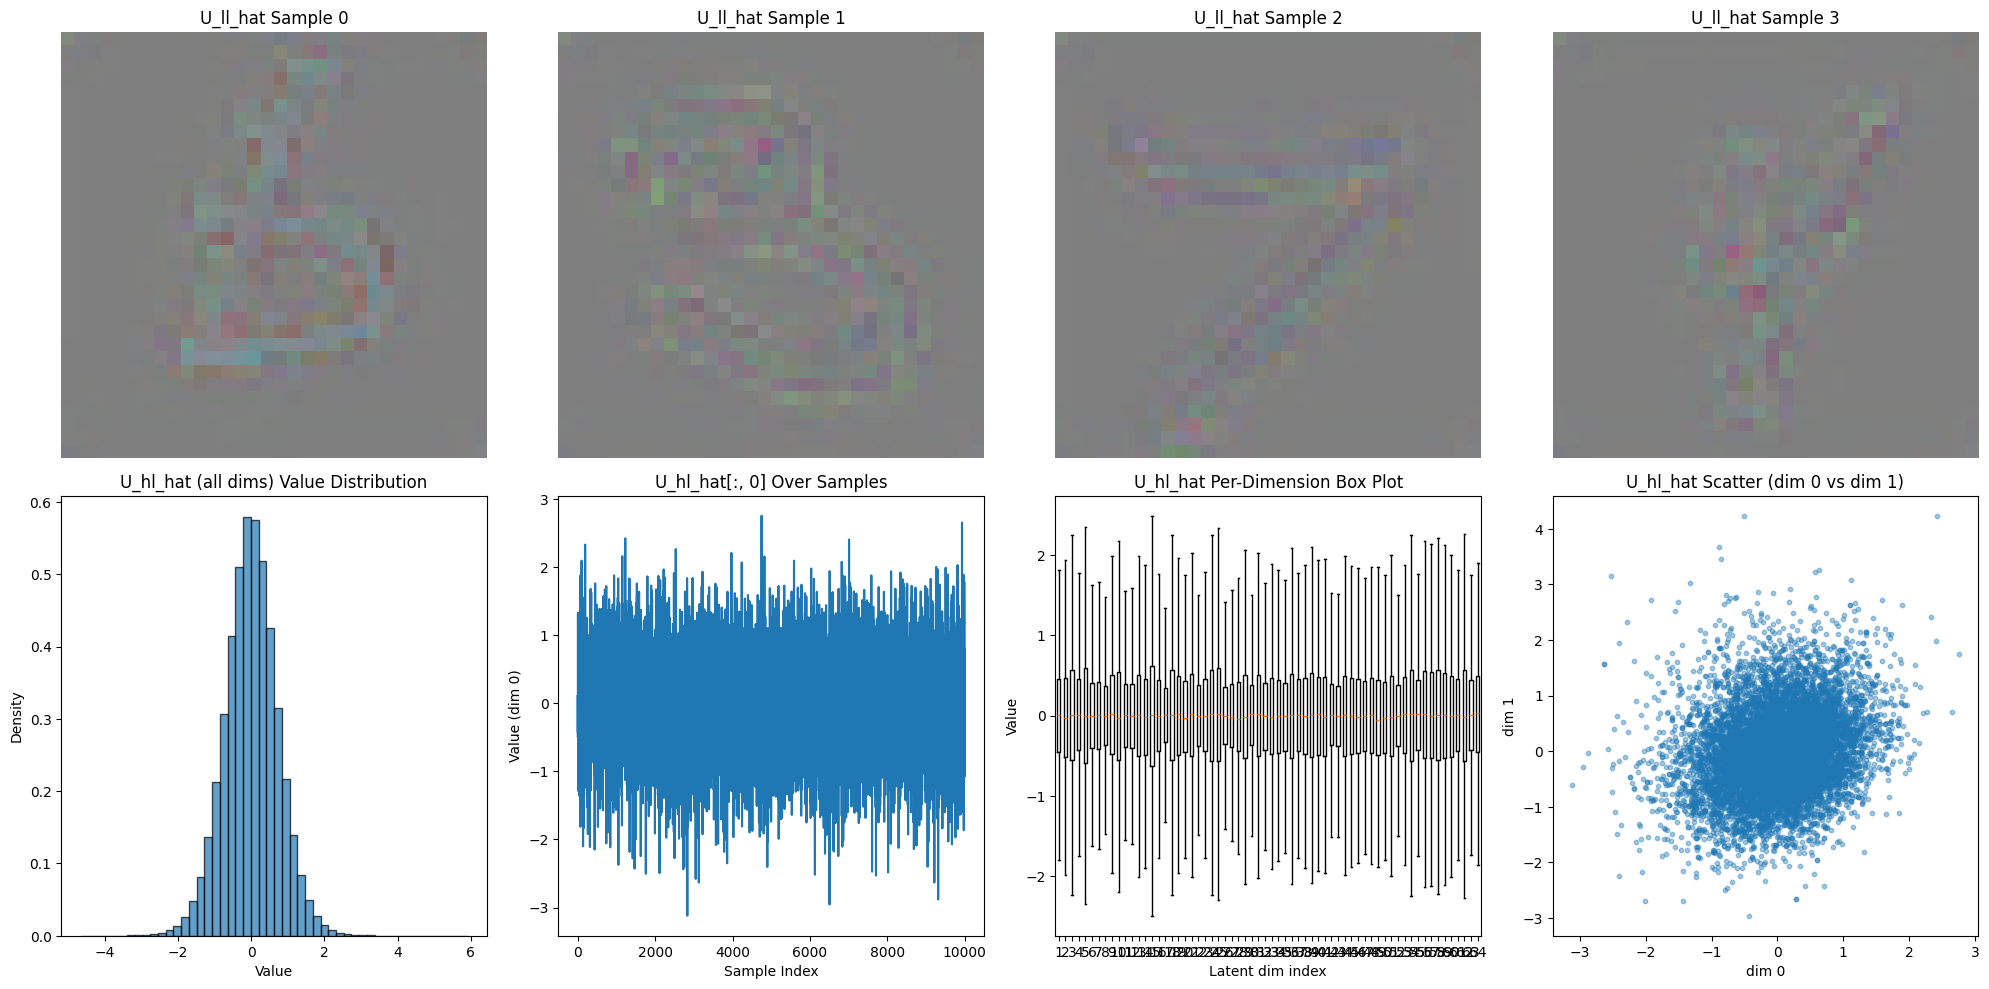


=== U_ll_hat Detailed Analysis ===
Per-channel statistics:
  Channel 0: mean=0.001709, std=0.033788
  Channel 1: mean=-0.000128, std=0.034306
  Channel 2: mean=0.002091, std=0.032564

U_ll_hat spatial statistics:
  Mean per pixel: 0.001224
  Std  per pixel: 0.004073
  Zero percentage: 0.00%

=== U_hl_hat (z-noise) Detailed Analysis ===
Value range (overall): [-4.656994, 5.912094]
Magnitude range (overall): 5.912094

Per-dimension stats (first few dims):
  dim 0: mean=0.001492, std=0.687359
  dim 1: mean=0.000142, std=0.771046
  dim 2: mean=-0.000025, std=0.860833
  dim 3: mean=-0.000820, std=0.706633
  dim 4: mean=-0.003226, std=0.898710

Outliers (1.5*IQR, overall): 9919/640000 (1.55%)
Near zero (<0.001, overall): 792/640000 (0.12%)


In [3]:
import matplotlib.pyplot as plt

# Analyze U_ll_hat and U_hl_hat (now z-noise with dim d_z)
print("=== U_ll_hat Analysis ===")
print(f"Shape: {U_ll_hat.shape}")
print(f"Data type: {U_ll_hat.dtype}")
print(f"Min value: {U_ll_hat.min().item():.6f}")
print(f"Max value: {U_ll_hat.max().item():.6f}")
print(f"Mean value: {U_ll_hat.mean().item():.6f}")
print(f"Std value: {U_ll_hat.std().item():.6f}")
nonzero_ll = (U_ll_hat != 0).sum().item()
print(f"Non-zero elements: {nonzero_ll}/{U_ll_hat.numel()} ({nonzero_ll/U_ll_hat.numel()*100:.2f}%)")

print("\n=== U_hl_hat (z-noise) Analysis ===")
print(f"Shape: {U_hl_hat.shape}")
print(f"Data type: {U_hl_hat.dtype}")
print(f"Latent dim d_z: {U_hl_hat.shape[1]}")
print(f"Min value (overall): {U_hl_hat.min().item():.6f}")
print(f"Max value (overall): {U_hl_hat.max().item():.6f}")
print(f"Mean value (overall): {U_hl_hat.mean().item():.6f}")
print(f"Std value (overall): {U_hl_hat.std().item():.6f}")
nonzero_hl = (U_hl_hat != 0).sum().item()
print(f"Non-zero elements: {nonzero_hl}/{U_hl_hat.numel()} ({nonzero_hl/U_hl_hat.numel()*100:.2f}%)")

# Create visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# ------------------------
# U_ll_hat visualizations
# ------------------------
# 1. Sample images from U_ll_hat (in [-1,1] space)
for i in range(min(4, U_ll_hat.shape[0])):
    ax = axes[0, i]
    img = U_ll_hat[i].detach().cpu().permute(1, 2, 0).numpy()
    if img.shape[2] == 1:
        img = img.squeeze(2)
        ax.imshow(img, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
    else:
        # show as RGB-ish noise, clipped
        ax.imshow(np.clip((img + 1) / 2, 0, 1))
    ax.set_title(f'U_ll_hat Sample {i}')
    ax.axis('off')

# ------------------------
# U_hl_hat visualizations
# ------------------------
U_hl_np = U_hl_hat.detach().cpu().numpy()
flat = U_hl_np.flatten()

# 2. Histogram of all U_hl_hat values
axes[1, 0].hist(flat, bins=50, alpha=0.7, edgecolor='black', density=True)
axes[1, 0].set_title('U_hl_hat (all dims) Value Distribution')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Density')

# 3. Line plot of first latent dimension over samples (if d_z >= 1)
if U_hl_np.shape[1] >= 1:
    axes[1, 1].plot(U_hl_np[:, 0])
    axes[1, 1].set_title('U_hl_hat[:, 0] Over Samples')
    axes[1, 1].set_xlabel('Sample Index')
    axes[1, 1].set_ylabel('Value (dim 0)')
else:
    axes[1, 1].text(0.5, 0.5, "d_z = 0?", ha='center', va='center')
    axes[1, 1].set_axis_off()

# 4. Box plot of per-dimension statistics
axes[1, 2].boxplot(U_hl_np, showfliers=False)
axes[1, 2].set_title('U_hl_hat Per-Dimension Box Plot')
axes[1, 2].set_xlabel('Latent dim index')
axes[1, 2].set_ylabel('Value')

# 5. Scatter of first two dimensions (if d_z >= 2)
if U_hl_np.shape[1] >= 2:
    axes[1, 3].scatter(U_hl_np[:, 0], U_hl_np[:, 1], alpha=0.4, s=10)
    axes[1, 3].set_xlabel('dim 0')
    axes[1, 3].set_ylabel('dim 1')
    axes[1, 3].set_title('U_hl_hat Scatter (dim 0 vs dim 1)')
else:
    axes[1, 3].plot(U_hl_np[:, 0], np.zeros_like(U_hl_np[:, 0]), '.', alpha=0.4)
    axes[1, 3].set_xlabel('dim 0')
    axes[1, 3].set_ylabel('dummy')
    axes[1, 3].set_title('U_hl_hat dim 0 (1D)')

plt.tight_layout()
plt.show()

# ------------------------
# Additional analysis for U_ll_hat
print("\n=== U_ll_hat Detailed Analysis ===")
print("Per-channel statistics:")
for c in range(U_ll_hat.shape[1]):
    channel_data = U_ll_hat[:, c, :, :]
    print(f"  Channel {c}: mean={channel_data.mean().item():.6f}, std={channel_data.std().item():.6f}")

print("\nU_ll_hat spatial statistics:")
print(f"  Mean per pixel: {U_ll_hat.mean(dim=0).mean().item():.6f}")
print(f"  Std  per pixel: {U_ll_hat.mean(dim=0).std().item():.6f}")

zero_percentage = (U_ll_hat == 0).sum().item() / U_ll_hat.numel() * 100
print(f"  Zero percentage: {zero_percentage:.2f}%")

# ------------------------
# Additional analysis for U_hl_hat (z)
# ------------------------
print("\n=== U_hl_hat (z-noise) Detailed Analysis ===")
print(f"Value range (overall): [{U_hl_hat.min().item():.6f}, {U_hl_hat.max().item():.6f}]")
print(f"Magnitude range (overall): {abs(U_hl_hat).max().item():.6f}")

# Per-dimension means/stds
print("\nPer-dimension stats (first few dims):")
max_dims_to_print = min(5, U_hl_hat.shape[1])
for d in range(max_dims_to_print):
    dim_vals = U_hl_hat[:, d]
    print(f"  dim {d}: mean={dim_vals.mean().item():.6f}, std={dim_vals.std().item():.6f}")

# Outliers on flattened distribution
q25, q75 = torch.quantile(U_hl_hat.flatten(), 0.25), torch.quantile(U_hl_hat.flatten(), 0.75)
iqr = q75 - q25
outlier_threshold = 1.5 * iqr
outliers = ((U_hl_hat < q25 - outlier_threshold) | (U_hl_hat > q75 + outlier_threshold)).sum().item()
print(f"\nOutliers (1.5*IQR, overall): {outliers}/{U_hl_hat.numel()} ({outliers/U_hl_hat.numel()*100:.2f}%)")

near_zero = (abs(U_hl_hat) < 1e-3).sum().item()
print(f"Near zero (<0.001, overall): {near_zero}/{U_hl_hat.numel()} ({near_zero/U_hl_hat.numel()*100:.2f}%)")


In [4]:
def det_hl_func(hl_model, parent_info_hl, intervention):
    """
    High-level deterministic function.

    Returns full high-level vectors:
        [one-hot digit (10), one-hot color (10), predicted latent z (d_z)]
    where z is predicted from (digit_onehot, color_onehot) by hl_model.
    """
    # parent_info_hl is a numpy array of shape (N, 20): [digit_onehot, color_onehot]
    features = parent_info_hl.copy()

    # Apply intervention on the labels if specified AND intervention object has .vv()
    if intervention is not None and hasattr(intervention, "vv"):
        iv_dict = intervention.vv()

        # Digit_ intervention
        if 'D_HL' in globals() and D_HL in iv_dict:
            new_digits = np.zeros_like(features[:, :10])
            new_digits[:, iv_dict[D_HL]] = 1
            features[:, :10] = new_digits

        # Color_ intervention
        if 'C_HL' in globals() and C_HL in iv_dict:
            new_colors = np.zeros_like(features[:, 10:20])
            new_colors[:, iv_dict[C_HL]] = 1
            features[:, 10:20] = new_colors

    # Predict latent z from (digit, color)
    # HLCellMeansShrunkVec.predict(X, Xc) -> use features for both arguments
    z_pred = hl_model.predict(features, features)          # shape: (N, d_z)

    # Ensure z_pred is 2D
    if z_pred.ndim == 1:
        z_pred = z_pred.reshape(-1, 1)

    # Full high-level deterministic vector: [digit_onehot, color_onehot, z_pred]
    full_vector = np.concatenate([features, z_pred], axis=1)  # shape: (N, 20 + d_z)
    return torch.tensor(full_vector, dtype=torch.float32)



def det_ll_func(ll_model, parent_info_ll_tuple, intervention):
    """
    Low-level deterministic function.

    Returns full low-level vectors:
        [flattened image (3072), one-hot digit (10), one-hot color (10)]
    from the U-Net generative model.
    """
    # Unpack data
    _, img_shapes, digits, colors = parent_info_ll_tuple
    n_samples = digits.shape[0]

    # Apply intervention to low-level labels if specified AND intervention has .vv()
    if intervention is not None and hasattr(intervention, "vv"):
        iv_dict = intervention.vv()
        if 'D_LL' in globals() and D_LL in iv_dict:
            digits = torch.full_like(digits, iv_dict[D_LL])
        if 'C_LL' in globals() and C_LL in iv_dict:
            colors = torch.full_like(colors, iv_dict[C_LL])

    # Forward pass through U-Net
    ll_model.eval()
    device = next(ll_model.parameters()).device
    img_shapes = img_shapes.to(device)
    digits = digits.to(device).long()
    colors = colors.to(device).long()

    with torch.no_grad():
        predicted_images = ll_model(img_shapes, digits, colors)

    # Flatten images
    flattened_images = predicted_images.cpu().view(n_samples, -1)  # (N, 3072)

    # One-hot labels
    digits_onehot = F.one_hot(digits.cpu(), num_classes=10).float()   # (N, 10)
    colors_onehot = F.one_hot(colors.cpu(), num_classes=10).float()   # (N, 10)

    # Full low-level deterministic vector: [pixels, digit_onehot, color_onehot]
    full_vector = torch.cat([flattened_images, digits_onehot, colors_onehot], dim=1)  # (N, 3092)
    return full_vector


# ---------- Find observational keys robustly ----------

def find_observational_key(sample_dict, name=""):
    """
    Try to find the key corresponding to observational data.
    Strategy:
      1. If None in keys, use that.
      2. Else, look for key with .vv() == {}.
      3. Else, fall back to the first key (with a warning).
    """
    keys = list(sample_dict.keys())

    # Case 1: explicit None key
    if None in sample_dict:
        return None

    # Case 2: scan for empty intervention
    for k in keys:
        if hasattr(k, "vv"):
            try:
                if k.vv() == {}:
                    return k
            except Exception:
                pass

    # Case 3: fallback
    fallback = keys[0]
    print(f"[Warning] Could not find explicit observational key for {name}. "
          f"Falling back to first key: {fallback}")
    return fallback


# ----- Parent information (observational) -----

# Low-level parent info (observational data)
iota_obs = find_observational_key(Dll_samples, name="Dll_samples")
final_images_obs, img_shapes_obs, digits_obs, colors_obs = Dll_samples[iota_obs]

parent_info_ll_tuple = (
    final_images_obs,  # final_images (unused directly, img_shapes used)
    img_shapes_obs,    # img_shapes
    digits_obs,        # digits
    colors_obs,        # colors
)

# High-level parent info (observational data):
eta_obs = find_observational_key(Dhl_samples, name="Dhl_samples")
# First 20 dims are always [digit_onehot (10), color_onehot (10)]
parent_info_hl = Dhl_samples[eta_obs][:, :20].cpu().numpy()

print(f"Observed LL key: {iota_obs}")
print(f"Observed HL key: {eta_obs}")
print(f"parent_info_ll_tuple shapes: "
      f"images={final_images_obs.shape}, img_shapes={img_shapes_obs.shape}, "
      f"digits={digits_obs.shape}, colors={colors_obs.shape}")
print(f"parent_info_hl shape: {parent_info_hl.shape}")

# ----- Compute deterministic outputs for all relevant interventions -----

# High-level (linear model to latent z)
det_hl_dict = {}
for eta in tqdm(Ihl_relevant, desc="Computing High-Level deterministic outputs (latent z)"):
    det_hl_dict[eta] = det_hl_func(hl_model, parent_info_hl, eta)
    
# Low-level (U-Net)
det_ll_dict = {}
for iota in tqdm(Ill_relevant, desc="Computing Low-Level deterministic outputs (U-Net)"):
    det_ll_dict[iota] = det_ll_func(ll_model, parent_info_ll_tuple, iota)


print(f"   - Low-level shape (obs key {iota_obs}): {det_ll_dict[iota_obs].shape}")
print(f"   - High-level shape (obs key {eta_obs}): {det_hl_dict[eta_obs].shape}")


[Warning] Could not find explicit observational key for Dll_samples. Falling back to first key: obs
[Warning] Could not find explicit observational key for Dhl_samples. Falling back to first key: obs
Observed LL key: obs
Observed HL key: obs
parent_info_ll_tuple shapes: images=torch.Size([10000, 3, 32, 32]), img_shapes=torch.Size([10000, 1, 32, 32]), digits=torch.Size([10000]), colors=torch.Size([10000])
parent_info_hl shape: (10000, 20)


Computing High-Level deterministic outputs (latent z): 100%|██████████| 10/10 [00:00<00:00, 200.06it/s]
Computing Low-Level deterministic outputs (U-Net): 100%|██████████| 10/10 [05:03<00:00, 30.31s/it]

   - Low-level shape (obs key obs): torch.Size([10000, 3092])
   - High-level shape (obs key obs): torch.Size([10000, 84])


In [5]:
# ================== SUBSAMPLE DATA FOR FASTER TRAINING ==================
import torch
import numpy as np

# How many samples you want to keep 
N_SUB = 1000  # e.g. 500 or 1000

print("\n" + "="*20 + f" Subsampling to N_SUB = {N_SUB} " + "="*20)

# ---- 0. Find observational key for LL & HL ----
iota_obs = find_observational_key(Dll_samples, name="Dll_samples")
eta_obs  = find_observational_key(Dhl_samples, name="Dhl_samples")
print(f"Using observational keys: iota_obs = {iota_obs}, eta_obs = {eta_obs}")

# ---- 1. Determine total N from observational environment ----
N_total = Dll_samples[iota_obs][0].shape[0]  # final_images shape[0]
print(f"Total available samples per intervention: N_total = {N_total}")

if N_SUB >= N_total:
    print("N_SUB >= N_total: no subsampling will be applied.")
    sub_idx = torch.arange(N_total, dtype=torch.long)
else:
    rng = np.random.default_rng(23)  # fixed for reproducibility
    perm = rng.permutation(N_total)
    sub_idx = torch.tensor(perm[:N_SUB], dtype=torch.long)
    print(f"Using a random subset of size {N_SUB} from {N_total} samples.")

# ---- 2. Subsample Dll_samples for ALL interventions ----
Dll_samples_full = Dll_samples  # backup
Dll_samples_sub = {}

for iota, tpl in Dll_samples.items():
    final_images, img_shapes, digits, colors = tpl
    Dll_samples_sub[iota] = (
        final_images[sub_idx],
        img_shapes[sub_idx],
        digits[sub_idx],
        colors[sub_idx],
    )

print(f"Dll_samples: reduced to N_SUB={Dll_samples_sub[iota_obs][0].shape[0]} for all interventions.")

# ---- 3. Subsample Dhl_samples for ALL interventions ----
Dhl_samples_full = Dhl_samples  # backup
Dhl_samples_sub = {}

for eta, tensor in Dhl_samples.items():
    Dhl_samples_sub[eta] = tensor[sub_idx]

print(f"Dhl_samples: reduced to N_SUB={Dhl_samples_sub[eta_obs].shape[0]} for all interventions.")

# ---- 4. Subsample noise estimates U_ll_hat and U_hl_hat ----
U_ll_hat_full = U_ll_hat  # backup
U_hl_hat_full = U_hl_hat  # backup

U_ll_hat_sub = U_ll_hat[sub_idx]
U_hl_hat_sub = U_hl_hat[sub_idx]

print(f"U_ll_hat: {U_ll_hat.shape} → {U_ll_hat_sub.shape}")
print(f"U_hl_hat: {U_hl_hat.shape} → {U_hl_hat_sub.shape}")

# (Optional) if you are using flattened versions U_ll_hat_fixed / U_hl_hat_fixed elsewhere:
if 'U_ll_hat_fixed' in locals():
    U_ll_hat_fixed_full = U_ll_hat_fixed
    U_ll_hat_fixed = U_ll_hat_fixed[sub_idx]
    print(f"U_ll_hat_fixed: {U_ll_hat_fixed_full.shape} → {U_ll_hat_fixed.shape}")
if 'U_hl_hat_fixed' in locals():
    U_hl_hat_fixed_full = U_hl_hat_fixed
    U_hl_hat_fixed = U_hl_hat_fixed[sub_idx]
    print(f"U_hl_hat_fixed: {U_hl_hat_fixed_full.shape} → {U_hl_hat_fixed.shape}")

# ---- 5. Subsample deterministic ANM outputs det_ll_dict & det_hl_dict ----
det_ll_dict_full = det_ll_dict  # backup
det_hl_dict_full = det_hl_dict  # backup

det_ll_dict_sub = {k: v[sub_idx] for k, v in det_ll_dict.items()}
det_hl_dict_sub = {k: v[sub_idx] for k, v in det_hl_dict.items()}

some_iota = next(iter(det_ll_dict_sub.keys()))
some_eta = next(iter(det_hl_dict_sub.keys()))
print(f"det_ll_dict[{some_iota!r}]: {det_ll_dict[some_iota].shape} → {det_ll_dict_sub[some_iota].shape}")
print(f"det_hl_dict[{some_eta!r}]: {det_hl_dict[some_eta].shape} → {det_hl_dict_sub[some_eta].shape}")

# ---- 6. Overwrite globals so the rest of the notebook uses the subset ----
Dll_samples = Dll_samples_sub
Dhl_samples = Dhl_samples_sub
U_ll_hat = U_ll_hat_sub
U_hl_hat = U_hl_hat_sub
det_ll_dict = det_ll_dict_sub
det_hl_dict = det_hl_dict_sub

print("\n✅ Subsampling complete. All subsequent training will use the reduced dataset.")



==================== Subsampling to N_SUB = 1000 ====================
[Warning] Could not find explicit observational key for Dll_samples. Falling back to first key: obs
[Warning] Could not find explicit observational key for Dhl_samples. Falling back to first key: obs
Using observational keys: iota_obs = obs, eta_obs = obs
Total available samples per intervention: N_total = 10000
Using a random subset of size 1000 from 10000 samples.
Dll_samples: reduced to N_SUB=1000 for all interventions.
Dhl_samples: reduced to N_SUB=1000 for all interventions.
U_ll_hat: torch.Size([10000, 3, 32, 32]) → torch.Size([1000, 3, 32, 32])
U_hl_hat: torch.Size([10000, 64]) → torch.Size([1000, 64])
det_ll_dict['obs']: torch.Size([10000, 3092]) → torch.Size([1000, 3092])
det_hl_dict['obs']: torch.Size([10000, 84]) → torch.Size([1000, 84])

✅ Subsampling complete. All subsequent training will use the reduced dataset.


In [6]:
from sklearn.model_selection import KFold
import numpy as np

print("\n" + "="*20 + " Setting up cross-validation " + "="*20)

# Reuse the observational LL key we already detected in the subsampling cell
# iota_obs is already defined there
print(f"Observational LL key: {iota_obs}")

K_FOLDS = 5
SEED = 23

def setup_cv_folds(data_tuple, n_splits=K_FOLDS, seed=SEED):
    """Create k-fold splits using the first tensor's length."""
    print(f"Setting up {n_splits}-fold cross-validation...")
    num_samples = data_tuple[0].shape[0]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for train_idx, test_idx in kf.split(np.arange(num_samples)):
        folds.append({'train': train_idx, 'test': test_idx})
    print(f"✓ CV folds created. Each fold will have ~{len(folds[0]['train'])} training samples.")
    return folds

# Create CV folds using the observational slice of *subsampled* Dll_samples
cv_folds = setup_cv_folds(Dll_samples[iota_obs])
print(f"Created {len(cv_folds)} CV folds (using observational key = {iota_obs})")



==================== Setting up cross-validation ====================
Observational LL key: obs
Setting up 5-fold cross-validation...
✓ CV folds created. Each fold will have ~800 training samples.
Created 5 CV folds (using observational key = obs)


In [7]:
def fix_noise_data(U_ll_hat, U_hl_hat):
    """
    Prepare noise data for optimization:
      - LL noise: flatten from (N, 3, 32, 32) → (N, 3072)
      - HL noise: leave as is (already (N, d_z))
    This now supports arbitrary #samples and arbitrary d_z.
    """
    N = U_ll_hat.shape[0]

    # --- Low-level noise ---
    if U_ll_hat.ndim == 4 and U_ll_hat.shape[1:] == (3, 32, 32):
        U_ll_hat_fixed = U_ll_hat.reshape(N, -1)  # (N, 3072)
        print(f"Flattened U_ll_hat from {tuple(U_ll_hat.shape)} → {tuple(U_ll_hat_fixed.shape)}")
    else:
        raise ValueError(f"Unexpected U_ll_hat shape: {U_ll_hat.shape}, expected (N,3,32,32)")

    # --- High-level noise ---
    if U_hl_hat.ndim == 2:
        U_hl_hat_fixed = U_hl_hat  # (N, d_z) already correct
        print(f"U_hl_hat retained as {tuple(U_hl_hat_fixed.shape)} (latent z noise)")
    else:
        raise ValueError(f"Unexpected U_hl_hat shape: {U_hl_hat.shape}, expected (N, d_z) 2D tensor")

    return U_ll_hat_fixed, U_hl_hat_fixed


# Run normalization
U_ll_hat_fixed, U_hl_hat_fixed = fix_noise_data(U_ll_hat, U_hl_hat)

print(f"\nFinal corrected shapes:")
print(f"  U_ll_hat_fixed: {tuple(U_ll_hat_fixed.shape)}")
print(f"  U_hl_hat_fixed: {tuple(U_hl_hat_fixed.shape)}")


Flattened U_ll_hat from (1000, 3, 32, 32) → (1000, 3072)
U_hl_hat retained as (1000, 64) (latent z noise)

Final corrected shapes:
  U_ll_hat_fixed: (1000, 3072)
  U_hl_hat_fixed: (1000, 64)


In [8]:
# --- Projection and Radius ---

def project_onto_frobenius_ball(tensor, radius_limit):
    """
    Project tensor onto a Frobenius norm ball:

        ||X||_F <= radius_limit

    Here radius_limit is the *total* norm constraint, typically something like
    sqrt(N) * epsilon when we interpret epsilon as a per-sample radius.
    """
    with torch.no_grad():
        current_norm = torch.norm(tensor, p='fro')
        if current_norm > radius_limit:
            # Scale down to lie exactly on the boundary
            tensor.mul_(radius_limit / (current_norm + 1e-12))
    return tensor


def compute_empirical_radius(N, eta=0.05, c1=1000.0, c2=1.0, alpha=2.0, m=1):
    """
    Compute an empirical Wasserstein-type radius (heuristic formula).

    Args:
        N    : number of samples
        eta  : confidence level
        c1,c2,alpha,m : constants from the chosen concentration result

    Returns:
        A scalar radius value.
    """
    if N <= 1:
        return 0.0
    term1 = c1 * (np.log(N) / N) ** (1.0 / alpha)
    term2 = c2 * np.sqrt(m * np.log(1.0 / eta) / N)
    return term1 + term2


# --- Abs-LiNGAM-style Core Functions (generic, now applied to 3092 -> 84) ---

def perfect_abstraction(px_samples, py_samples, tau_threshold=1e-2):
    """
    Fit a *dense* linear abstraction T_raw solving (in least-squares sense):

        px_samples @ T_raw ≈ py_samples

    where:
        px_samples : shape (N, D_ll_full)  e.g. D_ll_full = 3092
        py_samples : shape (N, D_hl_full)  e.g. D_hl_full = 84 (labels + latent z)

    Returns:
        T_raw with shape (D_ll_full, D_hl_full).

    A simple magnitude threshold tau_threshold is applied to zero out
    tiny coefficients.
    """
    # Pseudo-inverse solution: T_raw ∈ R^{D_ll_full × D_hl_full}
    T_raw = np.linalg.pinv(px_samples) @ py_samples

    # Hard threshold small coefficients
    T_raw_mask = np.abs(T_raw) > tau_threshold
    T_raw = T_raw * T_raw_mask
    return T_raw


def noisy_abstraction(px_samples, py_samples, tau_threshold=1e-1, refit_coeff=False):
    """
    Fit a *sparse / noisy* abstraction using an argmax-based masking scheme.

    Idea:
      1. First fit a dense T_raw_hat via pseudo-inverse:
             px_samples @ T_raw_hat ≈ py_samples
      2. For each low-level coordinate (row), keep only the strongest
         high-level dimension (argmax over |T_raw_hat[row, :]|).
      3. Apply an absolute-value threshold tau_threshold to optionally
         zero out weak connections.
      4. (Optionally) refit coefficients block-wise (refit_coeff=True).

    Args:
        px_samples : (N, D_ll_full)
        py_samples : (N, D_hl_full)
        tau_threshold : magnitude cutoff for keeping entries
        refit_coeff   : if True, do a second least-squares fit per HL block

    Returns:
        T_masked (or T_refit) with shape (D_ll_full, D_hl_full).
    """
    try:
        # 1) Dense reconstruction via pseudo-inverse
        #    px_samples^+ has shape (D_ll_full, N), so T_raw_hat is (D_ll_full, D_hl_full)
        T_raw_hat = np.linalg.pinv(px_samples) @ py_samples

        # 2) For each LL coordinate, pick HL dim with max |weight|
        tau_mask_indices = np.argmax(np.abs(T_raw_hat), axis=1)   # shape: (D_ll_full,)

        # 3) Build a one-hot mask over HL dims
        D_hl_full = py_samples.shape[1]
        tau_mask_hat = np.eye(D_hl_full)[tau_mask_indices]        # shape: (D_ll_full, D_hl_full)

        # 4) Only keep argmax entries whose magnitude exceeds tau_threshold
        tau_mask_hat *= np.array(np.abs(T_raw_hat) > tau_threshold, dtype=np.int32)

        # 5) Apply this combined mask
        T_masked = tau_mask_hat * T_raw_hat                       # shape: (D_ll_full, D_hl_full)

        if not refit_coeff:
            return T_masked

        # Optional: block-wise refitting per HL variable (more expensive, less tested)
        print("Warning: refit_coeff=True in noisy_abstraction is not fully verified.")
        T_refit = T_masked.copy()

        for j in range(D_hl_full):   # loop over HL dimensions
            block = np.where(tau_mask_hat[:, j] == 1)[0]  # LL dims mapping to this HL dim
            if len(block) == 0:
                continue
            try:
                # Solve: px_samples[:, block] @ T_block ≈ py_samples[:, j]
                T_block = np.linalg.pinv(px_samples[:, block]) @ py_samples[:, j]
                T_refit[block, j] = T_block
            except np.linalg.LinAlgError as e:
                print(f"Warning: pinv failed during refit for HL dim {j}: {e}. Skipping refit for this block.")

        return T_refit

    except np.linalg.LinAlgError as e:
        print(f"Error during pinv in noisy_abstraction: {e}")
        # Fallback: zero matrix with correct (D_ll_full, D_hl_full) shape
        return np.zeros((px_samples.shape[1], py_samples.shape[1]), dtype=px_samples.dtype)
    except Exception as e:
        print(f"Error in noisy_abstraction: {e}")
        return np.zeros((px_samples.shape[1], py_samples.shape[1]), dtype=px_samples.dtype)


In [9]:
def empirical_objective_cmnist_full(
    T,
    U_ll, U_hl,
    Theta_ll, Phi_hl,
    det_ll_dict, det_hl_dict,
    parent_info,  # unused, kept for API compatibility
    omega,
):
    """
    Objective for DiRoCA/GradCA in the new setting.

    Low level (per sample):
        det_ll_full : [pixels (3072), digit_onehot (10), color_onehot (10)] ∈ R^{3092}
        U_ll, Theta_ll : noise/perturbations ONLY on pixels ∈ R^{3072}

    High level (per sample):
        det_hl_full : [digit_onehot (10), color_onehot (10), z (64)] ∈ R^{84}
        U_hl, Phi_hl: noise/perturbations ONLY on latent z ∈ R^{64}

    T maps full LL vector to full HL vector:
        T ∈ R^{84 × 3092}
    """
    total_loss = 0.0
    device = T.device

    # Move noise/perturbations to device once
    U_ll = U_ll.to(device)       # (N, 3072)
    U_hl = U_hl.to(device)       # (N, 64)
    Theta_ll = Theta_ll.to(device)
    Phi_hl   = Phi_hl.to(device)

    num_interventions = 0

    for iota, eta in omega.items():
        if iota not in det_ll_dict or eta not in det_hl_dict:
            continue

        det_ll_full = det_ll_dict[iota].to(device)  # (N, 3092)
        det_hl_full = det_hl_dict[eta].to(device)   # (N, 84)

        # Batch-size consistency
        N = U_ll.shape[0]
        if det_ll_full.shape[0] != N or det_hl_full.shape[0] != N:
            continue

        # ----- Low level: pixels + labels -----
        ll_pixels      = det_ll_full[:, :3072]   # (N, 3072)
        ll_labels_part = det_ll_full[:, 3072:]   # (N, 20)
        ll_pixels_noisy = ll_pixels + U_ll + Theta_ll
        endo_ll_full    = torch.cat([ll_pixels_noisy, ll_labels_part], dim=1)  # (N, 3092)

        # ----- High level: labels + latent z -----
        hl_labels_part = det_hl_full[:, :20]     # (N, 20)  digit_onehot + color_onehot
        hl_z_part      = det_hl_full[:, 20:]     # (N, 64)  latent z
        hl_z_noisy     = hl_z_part + U_hl + Phi_hl
        endo_hl_full   = torch.cat([hl_labels_part, hl_z_noisy], dim=1)        # (N, 84)

        # ----- Apply abstraction and compute loss -----
        mapped_ll = (T @ endo_ll_full.T).T       # (N, 84)
        diff = mapped_ll - endo_hl_full
        loss = torch.norm(diff, p='fro')**2 / N  # average over samples
        total_loss += loss
        num_interventions += 1

    return total_loss / max(1, num_interventions)  # average over interventions


# --- Objective for BaryCA in the new latent-z setting ---
def barycentric_objective_cmnist(T, U_ll, U_hl, det_ll_dict, det_hl_dict, omega):
    """
    BaryCA objective: minimize error between T(apparent avg LL) and apparent avg HL.

    Here we average the deterministic components across interventions, then add
    the same noise U_ll (pixels) and U_hl (z) before applying T.
    """
    num_interventions = 0
    device = T.device

    # Move noise to device
    U_ll = U_ll.to(device)   # (N, 3072)
    U_hl = U_hl.to(device)   # (N, 64)

    # Collect deterministic LL/HL across interventions
    ll_tensors = []
    hl_tensors = []
    for iota, eta in omega.items():
        if iota in det_ll_dict and eta in det_hl_dict:
            ll_tensors.append(det_ll_dict[iota].to(device))  # (N, 3092)
            hl_tensors.append(det_hl_dict[eta].to(device))   # (N, 84)
            num_interventions += 1

    if num_interventions == 0:
        return torch.tensor(0.0, device=device)

    avg_det_ll = torch.mean(torch.stack(ll_tensors), dim=0)  # (N, 3092)
    avg_det_hl = torch.mean(torch.stack(hl_tensors), dim=0)  # (N, 84)
    N = avg_det_ll.shape[0]

    # ----- Average LL: pixels + labels -----
    avg_ll_pixels = avg_det_ll[:, :3072]    # (N, 3072)
    avg_ll_labels = avg_det_ll[:, 3072:]    # (N, 20)
    avg_noisy_ll  = torch.cat([avg_ll_pixels + U_ll, avg_ll_labels], dim=1)  # (N, 3092)

    # ----- Average HL: labels + latent z -----
    avg_hl_labels = avg_det_hl[:, :20]      # (N, 20)
    avg_hl_z      = avg_det_hl[:, 20:]      # (N, 64)
    avg_noisy_hl  = torch.cat([avg_hl_labels, avg_hl_z + U_hl], dim=1)       # (N, 84)

    # ----- Calculate error -----
    mapped_avg_ll = (T @ avg_noisy_ll.T).T  # (N, 84)
    diff = mapped_avg_ll - avg_noisy_hl
    loss = torch.norm(diff, p='fro')**2 / max(1, N)

    return loss

In [10]:
# --- Empirical Training Monitor ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

class EmpiricalMonitor:
    """
    Tracks metrics during empirical optimization (DiRoCA / GradCA / BaryCA).

    In our current ColorMNIST + latent-z setting:
      - T_objective: ANM reconstruction loss between mapped LL and HL
      - adv_objective: same objective evaluated at current adversary (for DiRoCA)
      - theta_norm: ||Theta_ll||_F, perturbations on LL pixels (N × 3072)
      - phi_norm:   ||Phi_hl||_F, perturbations on HL latent z (N × 64)
    """
    def __init__(self):
        self.iteration_history = []

    def track_iteration(
        self,
        iteration,
        T_objective,
        T_matrix,
        T_matrix_prev,
        adv_objective=None,
        Theta=None,
        Phi=None,
        epsilon=None,
        delta=None,
    ):
        metrics = {
            "iteration": iteration,
            "T_objective": T_objective.item()
                if isinstance(T_objective, torch.Tensor)
                else T_objective,
            "delta_T_norm": torch.norm(T_matrix - T_matrix_prev, p="fro").item()
                if T_matrix_prev is not None
                else 0.0,
        }

        # Adversary objective (only present for DiRoCA / ERICA)
        if adv_objective is not None and not (
            isinstance(adv_objective, float) and np.isnan(adv_objective)
        ):
            metrics["adv_objective"] = (
                adv_objective.item()
                if isinstance(adv_objective, torch.Tensor)
                else adv_objective
            )

        # Perturbation norms / boundaries
        if Theta is not None:
            metrics["theta_norm"] = torch.norm(Theta, p="fro").item()
            if epsilon is not None and Theta.shape[0] > 0:
                # Radius is epsilon * sqrt(N)
                metrics["epsilon_boundary"] = epsilon * np.sqrt(Theta.shape[0])
            else:
                metrics["epsilon_boundary"] = np.nan

        if Phi is not None:
            metrics["phi_norm"] = torch.norm(Phi, p="fro").item()
            if delta is not None and Phi.shape[0] > 0:
                metrics["delta_boundary"] = delta * np.sqrt(Phi.shape[0])
            else:
                metrics["delta_boundary"] = np.nan

        self.iteration_history.append(metrics)

    def plot_summary(self, title_prefix: str = ""):
        """Plot convergence diagnostics from the stored iteration history."""
        if not self.iteration_history:
            print("No history to plot.")
            return

        df = pd.DataFrame(self.iteration_history).set_index("iteration")

        num_plots = 2
        has_adv = "adv_objective" in df.columns and not df["adv_objective"].isnull().all()
        has_pert = "theta_norm" in df.columns and not df["theta_norm"].isnull().all()

        if has_adv:
            num_plots += 1
        if has_pert:
            num_plots += 1

        fig, axes = plt.subplots(
            num_plots, 1, figsize=(12, 4 * num_plots), sharex=True
        )
        if num_plots == 1:
            axes = [axes]

        fig.suptitle(
            f"{title_prefix} Optimization Convergence Summary",
            fontsize=16,
            y=1.02,
        )
        plot_idx = 0

        # 1. T objective
        axes[plot_idx].plot(
            df.index, df["T_objective"],
            marker=".", linestyle="-", label="T Objective (minimize)"
        )
        axes[plot_idx].set_ylabel("Objective Value")
        axes[plot_idx].set_title("Objective vs. Iteration")
        axes[plot_idx].grid(True, alpha=0.5)

        # 2. Adversary objective (if DiRoCA)
        if has_adv:
            # On same axis as T objective
            axes[plot_idx].plot(
                df.index, df["adv_objective"],
                marker=".", linestyle="-", color="orange",
                label="Adv. Objective (maximize)"
            )
            axes[plot_idx].legend()

            # Separate panel for adv objective
            plot_idx += 1
            axes[plot_idx].plot(
                df.index, df["adv_objective"],
                marker=".", linestyle="-", color="orange"
            )
            axes[plot_idx].set_ylabel("Objective Value")
            axes[plot_idx].set_title("Adversary Objective vs. Iteration")
            axes[plot_idx].grid(True, alpha=0.5)
        else:
            axes[plot_idx].legend()

        # 3. ||T_t - T_{t-1}||_F
        plot_idx += 1
        axes[plot_idx].plot(
            df.index, df["delta_T_norm"], marker=".", linestyle="-"
        )
        axes[plot_idx].set_ylabel("Frobenius Norm")
        axes[plot_idx].set_title("Change in T (||T_t - T_{t-1}||_F)")
        axes[plot_idx].set_yscale("log")
        axes[plot_idx].grid(True, alpha=0.5)

        # 4. Perturbation norms (if DiRoCA)
        if has_pert:
            plot_idx += 1
            axes[plot_idx].plot(
                df.index, df["theta_norm"],
                marker=".", linestyle="-", label="||Theta||_F (Low level)"
            )
            axes[plot_idx].plot(
                df.index, df["phi_norm"],
                marker=".", linestyle="-", label="||Phi||_F (High level)"
            )

            # Boundaries
            if "epsilon_boundary" in df.columns and not df["epsilon_boundary"].isnull().all():
                eps_val = df["epsilon_boundary"].dropna().iloc[0]
                axes[plot_idx].axhline(
                    eps_val, color="blue", linestyle="--", alpha=0.7,
                    label=f"Epsilon boundary ({eps_val:.1f})"
                )
            if "delta_boundary" in df.columns and not df["delta_boundary"].isnull().all():
                del_val = df["delta_boundary"].dropna().iloc[0]
                axes[plot_idx].axhline(
                    del_val, color="orange", linestyle="--", alpha=0.7,
                    label=f"Delta boundary ({del_val:.1f})"
                )

            axes[plot_idx].set_ylabel("Frobenius Norm")
            axes[plot_idx].set_title("Perturbation Norms vs. Iteration")
            axes[plot_idx].legend()
            axes[plot_idx].grid(True, alpha=0.5)

        axes[-1].set_xlabel("Iteration")
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()


In [11]:
import torch
import numpy as np
from tqdm import tqdm
import torch.optim as optim
import torch.nn.init as init  # For Xavier init

# --- Core DiRoCA / GradCA Optimizer ---
def run_empirical_erica_optimization_fixed(
    U_L, U_H,
    det_ll_dict, det_hl_dict, omega,
    epsilon, delta,
    eta_min, eta_max,
    num_steps_min, num_steps_max,
    max_iter, tol, seed,
    robust_L, robust_H,
    initialization, experiment, gain, optimizers,
    monitor=None
):
    """
    Core optimization loop for:
      - ERICA (robust_L or robust_H True): min over T, max over (Theta, Phi)
      - ENRICO / GradCA (both robust_* False): min over T only

    Current ColorMNIST + latent-z setting:
      U_L: (N, 3072)  — pixel noise at low level
      U_H: (N, 64)    — latent-z noise at high level
      det_ll_dict[iota]: (N, 3092) = [pixels (3072), one-hot labels (20)]
      det_hl_dict[eta]:  (N, 84)   = [one-hot labels (20), z (64)]
      T: (84, 3092) maps LL full vectors → HL full vectors
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    # --- Device Setup ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    Ill = list(det_ll_dict.keys())
    method = "erica" if robust_L or robust_H else "enrico"

    # --- Data Prep ---
    U_L = torch.as_tensor(U_L, dtype=torch.float32).to(device)
    U_H = torch.as_tensor(U_H, dtype=torch.float32).to(device)
    if U_L.ndim > 2:
        U_L = U_L.view(U_L.shape[0], -1)
    if U_H.ndim > 2:
        U_H = U_H.view(U_H.shape[0], -1)

    N, l = U_L.shape      # l = 3072 (pixels)
    _, h = U_H.shape      # h = 64 (latent z)
    l_full, h_full = 3092, 84  # full LL dim, full HL dim (20 labels + 64 z)

    # Move det_dicts to device once
    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}

    # --- Initialization of T ---
    T = torch.randn(h_full, l_full, requires_grad=True, device=device)
    if gain > 0:
        init.xavier_normal_(T, gain=gain)

    # --- Initialization of Theta, Phi ---
    # Theta: (N, 3072), Phi: (N, 64)
    requires_grad_adv = (method == "erica")
    if initialization == "zeros":
        Theta = torch.zeros(N, l, requires_grad=requires_grad_adv, device=device)
        Phi   = torch.zeros(N, h, requires_grad=requires_grad_adv, device=device)
    elif initialization == "random":
        Theta = torch.randn(N, l, requires_grad=requires_grad_adv, device=device)
        Phi   = torch.randn(N, h, requires_grad=requires_grad_adv, device=device)
    else:
        raise ValueError(f"Unknown initialization: {initialization}")

    # --- Optimizers ---
    optimizer_T_params = [T]
    optimizer_max_params = [Theta, Phi] if method == "erica" else []

    if optimizers == "adam":
        optimizer_T = optim.Adam(optimizer_T_params, lr=eta_min)
        if optimizer_max_params:
            optimizer_max = optim.Adam(optimizer_max_params, lr=eta_max)
    elif optimizers == "adam_betas":
        optimizer_T = optim.Adam(
            optimizer_T_params,
            lr=eta_min,
            betas=(0.9, 0.999),
            eps=1e-8,
            amsgrad=True,
        )
        if optimizer_max_params:
            optimizer_max = optim.Adam(
                optimizer_max_params,
                lr=eta_max,
                betas=(0.9, 0.999),
                eps=1e-8,
                amsgrad=True,
            )
    else:
        raise ValueError(f"Unknown optimizer: {optimizers}")

    prev_T_objective = float("inf")
    T_prev = None
    if monitor is None:
        monitor = EmpiricalMonitor()

    # --- Optimization Loop ---
    for iteration in tqdm(range(max_iter), desc=f"{method.upper()} Optimization"):
        T_prev = T.detach().clone()
        final_T_objective_in_iter = torch.tensor(np.nan, device=device)
        final_adv_objective_in_iter = torch.tensor(np.nan, device=device)

        # --- Step 1: Minimize over T ---
        for _ in range(num_steps_min):
            optimizer_T.zero_grad()

            T_objective = empirical_objective_cmnist_full(
                T, U_L, U_H,
                Theta.detach(), Phi.detach(),  # detach adversary during T-update
                det_ll_dict_dev, det_hl_dict_dev,
                parent_info=None,
                omega=omega,
            )

            if torch.isnan(T_objective):
                print(f"\nNaN encountered in T objective at iter {iteration + 1}. Stopping.")
                T_final = T_prev.cpu().numpy()
                paramsL = {
                    "pert_U": Theta.detach().cpu().numpy(),
                    "radius_worst": epsilon if method == "erica" else 0,
                    "pert_hat": U_L.cpu().numpy(),
                    "radius": epsilon if method == "erica" else 0,
                }
                paramsH = {
                    "pert_U": Phi.detach().cpu().numpy(),
                    "radius_worst": delta if method == "erica" else 0,
                    "pert_hat": U_H.cpu().numpy(),
                    "radius": delta if method == "erica" else 0,
                }
                opt_params = {"L": paramsL, "H": paramsH}
                return opt_params, T_final, Theta.detach().cpu().numpy(), Phi.detach().cpu().numpy(), monitor

            T_objective.backward()
            optimizer_T.step()
            final_T_objective_in_iter = T_objective

        # --- Step 2: Maximize over Theta, Phi (ERICA only) ---
        if method == "erica":
            for _ in range(num_steps_max):
                optimizer_max.zero_grad()

                max_objective = -empirical_objective_cmnist_full(
                    T.detach(), U_L, U_H,
                    Theta, Phi,
                    det_ll_dict_dev, det_hl_dict_dev,
                    parent_info=None,
                    omega=omega,
                )

                if torch.isnan(max_objective):
                    print(f"\nNaN encountered in Max objective at iter {iteration + 1}. Using previous Theta/Phi.")
                    optimizer_max.zero_grad()
                    break

                max_objective.backward()
                optimizer_max.step()

                # Project onto Frobenius balls for perturbations
                with torch.no_grad():
                    max_norm_theta = epsilon * np.sqrt(N) if epsilon > 0 else 0.0
                    max_norm_phi   = delta   * np.sqrt(N) if delta   > 0 else 0.0

                    if max_norm_theta > 0:
                        Theta.data = project_onto_frobenius_ball(Theta, max_norm_theta)
                    if max_norm_phi > 0:
                        Phi.data   = project_onto_frobenius_ball(Phi,   max_norm_phi)

            # Final adversary objective after projection (same loss, not negated)
            with torch.no_grad():
                final_adv_objective_in_iter = empirical_objective_cmnist_full(
                    T, U_L, U_H,
                    Theta, Phi,
                    det_ll_dict_dev, det_hl_dict_dev,
                    parent_info=None,
                    omega=omega,
                )
        else:
            # GradCA / ENRICO: adversary fixed at zero
            final_adv_objective_in_iter = final_T_objective_in_iter
            Theta.zero_()
            Phi.zero_()

        # --- Track metrics ---
        t_obj_item = (
            final_T_objective_in_iter.item()
            if torch.isfinite(final_T_objective_in_iter)
            else np.nan
        )
        adv_obj_item = (
            final_adv_objective_in_iter.item()
            if torch.isfinite(final_adv_objective_in_iter)
            else np.nan
        )

        monitor.track_iteration(
            iteration=iteration + 1,
            T_objective=t_obj_item,
            T_matrix=T,
            T_matrix_prev=T_prev,
            adv_objective=adv_obj_item if method == "erica" else None,
            Theta=Theta if method == "erica" else None,
            Phi=Phi if method == "erica" else None,
            epsilon=epsilon if method == "erica" else None,
            delta=delta if method == "erica" else None,
        )

        # --- Convergence Check ---
        if not np.isnan(t_obj_item):
            if abs(prev_T_objective - t_obj_item) < tol:
                print(f"\nConverged at iteration {iteration + 1} (delta_obj < {tol})")
                break
            prev_T_objective = t_obj_item
        elif iteration > 0:
            print(f"\nStopping early due to NaN objective at iteration {iteration + 1}")
            break

    # --- Final Steps ---
    T_final = T.detach().cpu().numpy()

    monitor.plot_summary(title_prefix=f"{method.upper()} Fold (Seed {seed})")

    Theta_final_np = Theta.detach().cpu().numpy()
    Phi_final_np   = Phi.detach().cpu().numpy()

    paramsL = {
        "pert_U": Theta_final_np,
        "radius_worst": epsilon if method == "erica" else 0,
        "pert_hat": U_L.cpu().numpy(),
        "radius": epsilon if method == "erica" else 0,
    }
    paramsH = {
        "pert_U": Phi_final_np,
        "radius_worst": delta if method == "erica" else 0,
        "pert_hat": U_H.cpu().numpy(),
        "radius": delta if method == "erica" else 0,
    }
    opt_params = {"L": paramsL, "H": paramsH}

    return opt_params, T_final, Theta_final_np, Phi_final_np, monitor


# --- Core BaryCA Optimizer ---
def run_empirical_bary_optim_cmnist(
    U_ll_hat, U_hl_hat,
    det_ll_dict, det_hl_dict, omega,
    lr=1e-3, max_iter=5000, tol=1e-5, seed=42,
    monitor=None
):
    """
    Core optimization loop for BaryCA with monitoring.

    Uses barycentric_objective_cmnist, with:
      U_ll_hat: (N, 3072) LL noise
      U_hl_hat: (N, 64)   HL latent z noise
      T: (84, 3092)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Data Prep ---
    U_ll_hat = torch.as_tensor(U_ll_hat, dtype=torch.float32).to(device)
    U_hl_hat = torch.as_tensor(U_hl_hat, dtype=torch.float32).to(device)
    if U_ll_hat.ndim > 2:
        U_ll_hat = U_ll_hat.view(U_ll_hat.shape[0], -1)
    if U_hl_hat.ndim > 2:
        U_hl_hat = U_hl_hat.view(U_hl_hat.shape[0], -1)

    l_full, h_full = 3092, 84

    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}

    # --- Initialization ---
    T = torch.randn(h_full, l_full, requires_grad=True, device=device)
    optimizer = optim.Adam([T], lr=lr)
    prev_loss = float("inf")
    T_prev = None
    if monitor is None:
        monitor = EmpiricalMonitor()

    # --- Optimization Loop ---
    for iteration in tqdm(range(max_iter), desc="BaryCA Optimization"):
        T_prev = T.detach().clone()

        optimizer.zero_grad()
        loss = barycentric_objective_cmnist(
            T, U_ll_hat, U_hl_hat,
            det_ll_dict_dev, det_hl_dict_dev,
            omega,
        )
        if torch.isnan(loss):
            print(f"NaN loss encountered at iteration {iteration}. Stopping.")
            break

        loss.backward()
        optimizer.step()

        current_loss_item = loss.item()

        monitor.track_iteration(
            iteration=iteration + 1,
            T_objective=current_loss_item,
            T_matrix=T,
            T_matrix_prev=T_prev,
        )

        if iteration % 200 == 0:
            tqdm.write(f"Iter {iteration}, Loss: {current_loss_item:.6f}")

        if abs(prev_loss - current_loss_item) < tol:
            print(f"Converged at iteration {iteration}")
            break
        prev_loss = current_loss_item

    print(f"Final BaryCA loss: {current_loss_item:.6f}")
    monitor.plot_summary(title_prefix=f"BaryCA Fold (Seed {seed})")

    return T.detach().cpu().numpy(), monitor


# --- Core Abs-LiNGAM Calculation ---
def run_abs_lingam_cmnist(
    Dll_obs_full, Dhl_obs_full,
    tau_perfect=1e-2, tau_noisy=1e-1
):
    """
    Runs Abs-LiNGAM assuming *full* LL/HL vectors are passed:

      Dll_obs_full: (N, 3092) = [pixels (3072), labels one-hot (20)]
      Dhl_obs_full: (N, 84)   = [labels one-hot (20), latent z (64)]

    Returns T mapping LL → HL with shape (84, 3092).
    """
    if isinstance(Dll_obs_full, torch.Tensor):
        Dll_obs_full = Dll_obs_full.cpu().numpy()
    if isinstance(Dhl_obs_full, torch.Tensor):
        Dhl_obs_full = Dhl_obs_full.cpu().numpy()

    try:
        if Dll_obs_full.shape[1] != 3092:
            raise ValueError(f"Expected Dll_obs_full to have 3092 columns, got {Dll_obs_full.shape[1]}")
        if Dhl_obs_full.shape[1] != 84:
            raise ValueError(f"Expected Dhl_obs_full to have 84 columns, got {Dhl_obs_full.shape[1]}")

        T_perfect_raw = perfect_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_perfect)
        T_noisy_raw   = noisy_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_noisy, refit_coeff=False)

        # perfect_abstraction / noisy_abstraction return (D_ll, D_hl)
        # We transpose to get (D_hl, D_ll) = (84, 3092)
        T_perfect = T_perfect_raw.T.astype(np.float32)
        T_noisy   = T_noisy_raw.T.astype(np.float32)

        return {
            "Perfect": {"T": T_perfect},
            "Noisy":   {"T": T_noisy},
        }
    except Exception as e:
        print(f"ERROR during Abs-LiNGAM: {e}")
        return {
            "Perfect": {"T": None},
            "Noisy":   {"T": None},
        }


print("Core optimization functions defined for latent-z HL (dim 84).")


Core optimization functions defined for latent-z HL (dim 84).


In [12]:
import torch
import numpy as np
import os
import gc
import torch.nn.functional as F  # (kept in case you need it elsewhere)

# --- Wrapper for DiRoCA (ERICA) ---
def train_diroca_single_run(
    cv_folds,
    U_ll_hat, U_hl_hat,
    det_ll_dict, det_hl_dict,
    omega,
    run_hyperparams, fixed_params,
    epsilon, delta
):
    """
    Wrapper to train DiRoCA/ERICA across all CV folds.

    Uses:
      U_ll_hat: (N, 3072) low-level noise
      U_hl_hat: (N, 64)   high-level latent z noise
      det_ll_dict[k]: (N, 3092)
      det_hl_dict[k]: (N, 84)
    """
    print(f"Starting DiRoCA Training Run: eps={epsilon}, del={delta}")
    print(f"Hyperparameters: {run_hyperparams}")

    diroca_training_results = {}
    monitors = {}

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Noise slices (train split)
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2:
            U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2:
            U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Deterministic components (train split)
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {**fixed_params, **run_hyperparams}
        fold_monitor = EmpiricalMonitor()

        run_args = {
            "U_L": U_ll_train,
            "U_H": U_hl_train,
            "det_ll_dict": det_ll_train,
            "det_hl_dict": det_hl_train,
            "omega": omega,
            "epsilon": epsilon,
            "delta": delta,
            **current_run_params,
            "monitor": fold_monitor,
        }

        try:
            opt_params, trained_T, final_Theta, final_Phi, trained_monitor = (
                run_empirical_erica_optimization_fixed(**run_args)
            )

            method_key = f"eps_{epsilon}_delta_{delta}"
            diroca_training_results[fold_key] = {
                method_key: {
                    "T_matrix": torch.tensor(trained_T, dtype=torch.float32),
                    "optimization_params": opt_params,
                    "test_indices": test_indices,
                    "epsilon": epsilon,
                    "delta": delta,
                    "final_Theta_ll": final_Theta,
                    "final_Phi_hl": final_Phi,
                }
            }
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            diroca_training_results[fold_key] = {"error": str(e)}
            monitors[fold_key] = None
        break
    print("\nDiRoCA Training complete.")
    return {"diroca": diroca_training_results}, monitors


# --- Wrapper for GradCA (non-robust) ---
def train_gradca_single_run(
    cv_folds,
    U_ll_hat, U_hl_hat,
    det_ll_dict, det_hl_dict,
    omega,
    run_hyperparams, fixed_params
):
    """
    Wrapper to train GradCA (non-robust, epsilon=delta=0) across all CV folds.
    """
    print("Starting GradCA Training...")
    print(f"Hyperparameters: {run_hyperparams}")

    gradca_training_results = {}
    monitors = {}
    gradca_hyperparams = run_hyperparams.copy()

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Noise slices
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2:
            U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2:
            U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Deterministic components
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {
            **fixed_params,
            **gradca_hyperparams,
            "eta_max": gradca_hyperparams.get("eta_max", 0.0),
            "num_steps_max": gradca_hyperparams.get("num_steps_max", 0),
        }
        fold_monitor = EmpiricalMonitor()

        run_args = {
            "U_L": U_ll_train,
            "U_H": U_hl_train,
            "det_ll_dict": det_ll_train,
            "det_hl_dict": det_hl_train,
            "omega": omega,
            "epsilon": 0.0,
            "delta": 0.0,
            "robust_L": False,
            "robust_H": False,
            **current_run_params,
            "monitor": fold_monitor,
        }

        try:
            opt_params, trained_T, _, _, trained_monitor = (
                run_empirical_erica_optimization_fixed(**run_args)
            )

            method_key = "gradca_run"
            gradca_training_results[fold_key] = {
                method_key: {
                    "T_matrix": torch.tensor(trained_T, dtype=torch.float32),
                    "optimization_params": opt_params,
                    "test_indices": test_indices,
                }
            }
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            gradca_training_results[fold_key] = {"error": str(e)}
            monitors[fold_key] = None
        break
    print("\nGradCA Training complete.")
    return {"gradca": gradca_training_results}, monitors


# --- Wrapper for BaryCA ---
def train_baryca_single_run(
    cv_folds,
    U_ll_hat, U_hl_hat,
    det_ll_dict, det_hl_dict,
    omega,
    run_hyperparams, fixed_params,
):
    """
    Wrapper to train BaryCA across all CV folds.
    """
    print("Starting BaryCA Training...")
    print(f"Hyperparameters: {run_hyperparams}")

    baryca_training_results = {}
    monitors = {}
    baryca_hyperparams = run_hyperparams

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Noise slices
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2:
            U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2:
            U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Deterministic components
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        fold_monitor = EmpiricalMonitor()
        run_args = {
            "U_ll_hat": U_ll_train,
            "U_hl_hat": U_hl_train,
            "det_ll_dict": det_ll_train,
            "det_hl_dict": det_hl_train,
            "omega": omega,
            "seed": fixed_params["seed"],
            **baryca_hyperparams,
            "monitor": fold_monitor,
        }

        try:
            trained_T, trained_monitor = run_empirical_bary_optim_cmnist(**run_args)
            method_key = "baryca_run"
            baryca_training_results[fold_key] = {
                method_key: {
                    "T_matrix": torch.tensor(trained_T, dtype=torch.float32),
                    "test_indices": test_indices,
                }
            }
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            baryca_training_results[fold_key] = {"error": str(e)}
            monitors[fold_key] = None
        break
    print("\nBaryCA Training complete.")
    return {"baryca": baryca_training_results}, monitors


# --- Wrapper for Abs-LiNGAM ---
def train_abslingam_single_run(
    cv_folds,
    det_ll_dict, det_hl_dict,
    run_hyperparams,
    obs_key: str = "obs",
):
    """
    Wrapper to compute Abs-LiNGAM for all folds, using the *observational*
    full LL/HL vectors from det_ll_dict/det_hl_dict.

    Assumes:
      det_ll_dict[obs_key]: (N, 3092)
      det_hl_dict[obs_key]: (N, 84)
    """
    print("Starting Abs-LiNGAM Training...")
    print(f"Hyperparameters: {run_hyperparams}")  # thresholds mainly

    abslingam_training_results = {}
    tau_p = run_hyperparams.get("tau_perfect", 1e-2)
    tau_n = run_hyperparams.get("tau_noisy", 1e-1)

    # Check observational key
    if obs_key not in det_ll_dict or obs_key not in det_hl_dict:
        print(f"[Error] obs_key='{obs_key}' not found in det_ll_dict or det_hl_dict.")
        return {"abslingam": {"error": f"obs_key '{obs_key}' not found"}}

    Dll_obs_full_all = det_ll_dict[obs_key]  # (N, 3092)
    Dhl_obs_full_all = det_hl_dict[obs_key]  # (N, 84)

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Restrict to training indices for this fold
        Dll_obs_full = Dll_obs_full_all[train_indices]
        Dhl_obs_full = Dhl_obs_full_all[train_indices]

        try:
            # Run Abs-LiNGAM calculation on train split
            abslingam_run_result = run_abs_lingam_cmnist(
                Dll_obs_full, Dhl_obs_full,
                tau_p, tau_n
            )

            abslingam_training_results[fold_key] = {}

            if abslingam_run_result["Perfect"]["T"] is not None:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Perfect)"] = {
                    "T_matrix": torch.tensor(
                        abslingam_run_result["Perfect"]["T"],
                        dtype=torch.float32,
                    ),
                    "test_indices": test_indices,
                }
            else:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Perfect)"] = {
                    "error": "Calculation Failed"
                }

            if abslingam_run_result["Noisy"]["T"] is not None:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Noisy)"] = {
                    "T_matrix": torch.tensor(
                        abslingam_run_result["Noisy"]["T"],
                        dtype=torch.float32,
                    ),
                    "test_indices": test_indices,
                }
            else:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Noisy)"] = {
                    "error": "Calculation Failed"
                }

            print(f"  ✓ Computation completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during computation for Fold {i+1}: {e}")
            abslingam_training_results[fold_key] = {"error": str(e)}
        break
    print("\nAbs-LiNGAM Computation complete.")
    return {"abslingam": abslingam_training_results}


print("All optimization and wrapper functions defined for latent-z ColorMNIST setting.")


All optimization and wrapper functions defined for latent-z ColorMNIST setting.



==================== Training DiRoCA Multiple Radii ====================
Using U_ll_hat_run with shape: torch.Size([1000, 3072])
Using U_hl_hat_run with shape: torch.Size([1000, 64])

Running DiRoCA for 4 radius combinations...

--- Running DiRoCA 1/4: ε=1.0, δ=0.0 ---
Starting DiRoCA Training Run: eps=1.0, del=0.0
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization: 100%|██████████| 10000/10000 [2:38:11<00:00,  1.05it/s]  


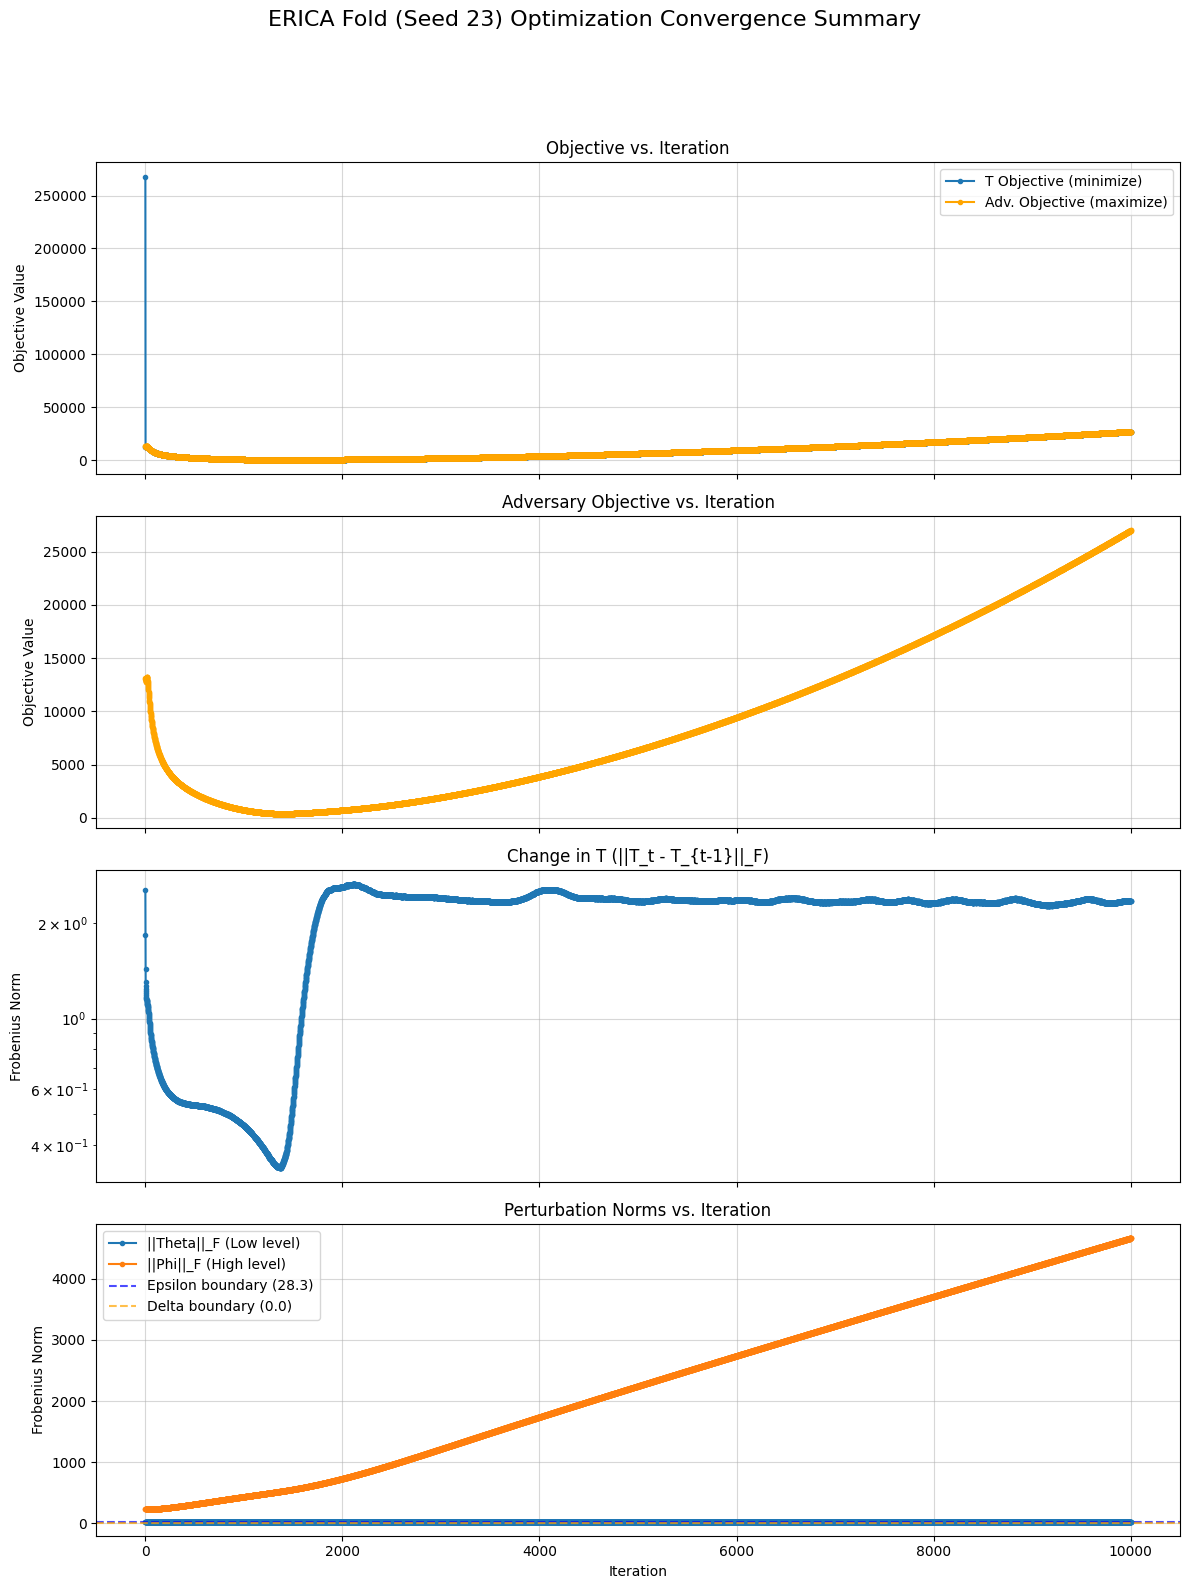

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_1.0_delta_0.0

--- Running DiRoCA 2/4: ε=2.0, δ=0.0 ---
Starting DiRoCA Training Run: eps=2.0, del=0.0
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization: 100%|██████████| 10000/10000 [2:56:01<00:00,  1.06s/it] 


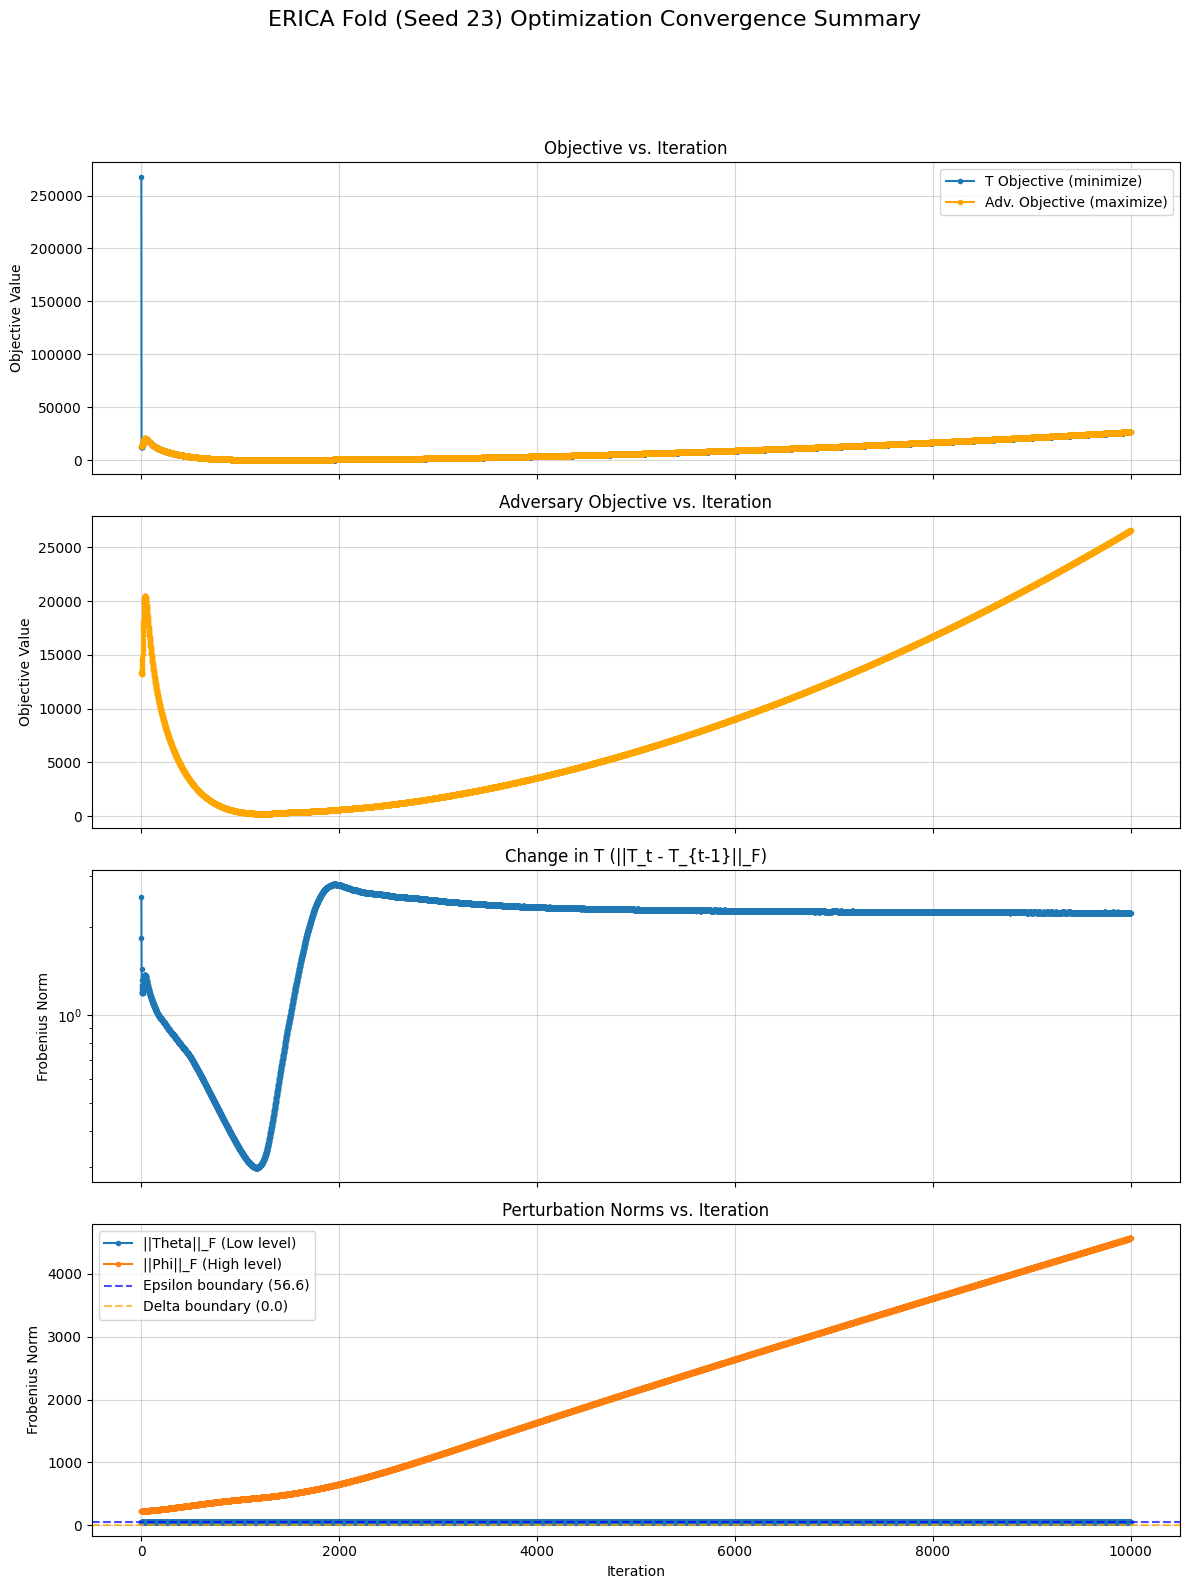

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_2.0_delta_0.0

--- Running DiRoCA 3/4: ε=4.0, δ=0.0 ---
Starting DiRoCA Training Run: eps=4.0, del=0.0
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization:  12%|█▏        | 1249/10000 [22:56<2:40:47,  1.10s/it]


Converged at iteration 1250 (delta_obj < 0.0001)


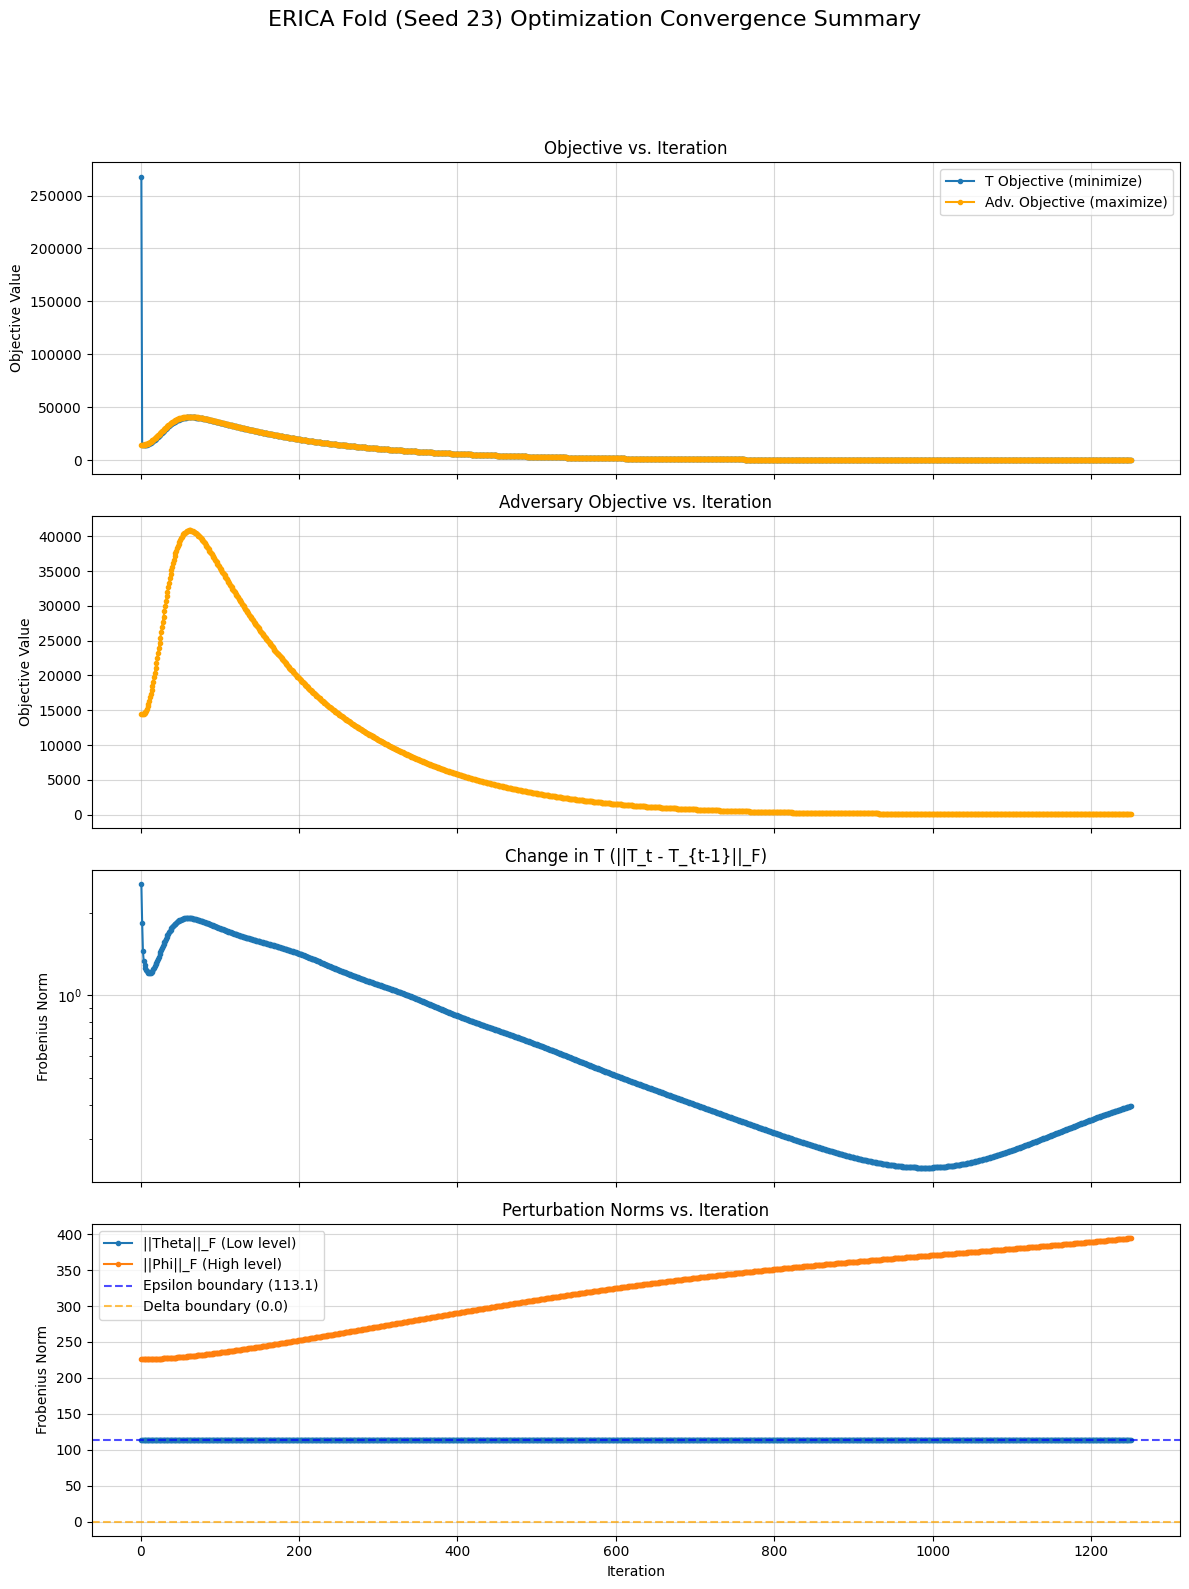

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_4.0_delta_0.0

--- Running DiRoCA 4/4: ε=8.0, δ=0.0 ---
Starting DiRoCA Training Run: eps=8.0, del=0.0
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization:  13%|█▎        | 1318/10000 [24:12<2:39:28,  1.10s/it]


Converged at iteration 1319 (delta_obj < 0.0001)


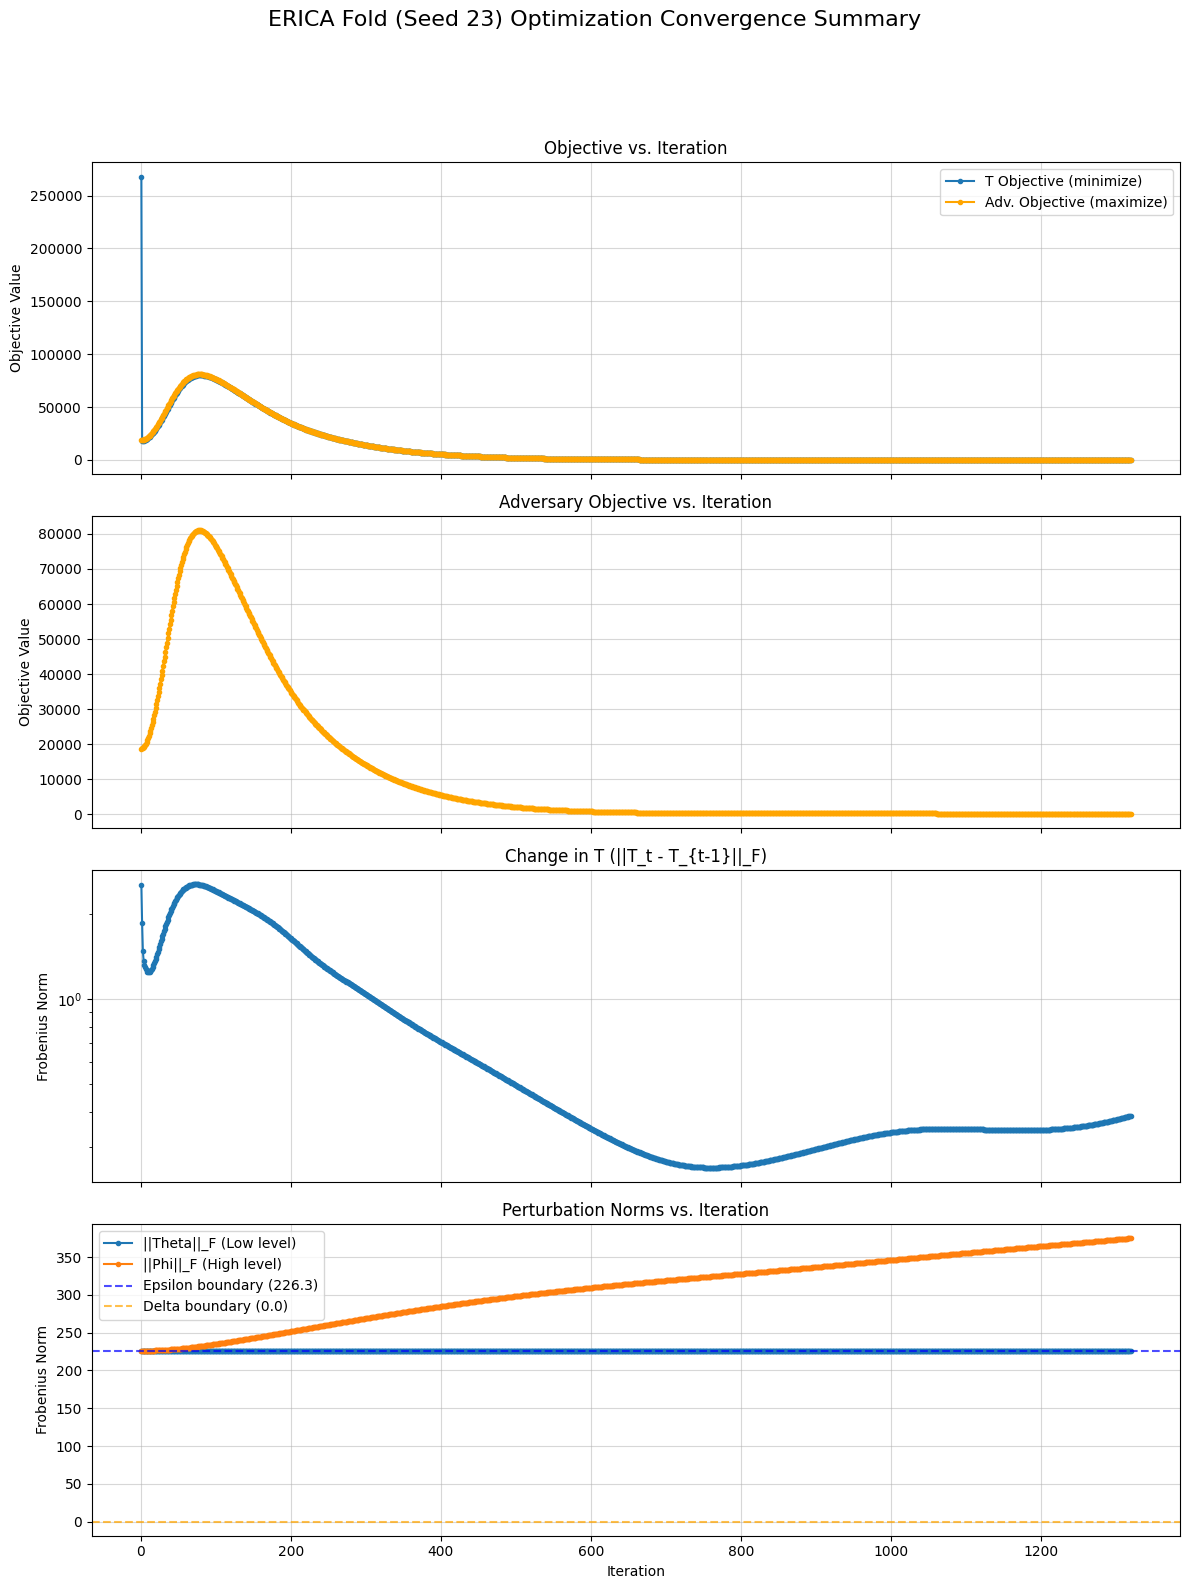

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_8.0_delta_0.0

DiRoCA Multi-Radius Training Complete!

Results Summary:
  ✓ eps_1.0_delta_0.0: Success
  ✓ eps_2.0_delta_0.0: Success
  ✓ eps_4.0_delta_0.0: Success
  ✓ eps_8.0_delta_0.0: Success


In [14]:
import torch
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("\n" + "="*20 + " Training DiRoCA Multiple Radii " + "="*20)

# --- Hyperparameters for DiRoCA ---
diroca_hyperparams = {
    'eta_min': 1e-3,
    'eta_max': 1e-3,
    'max_iter': 10000,
    'num_steps_min': 5,
    'num_steps_max': 2,
    'initialization': 'random',
    'optimizers': 'adam',
}

fixed_params_diroca = {
    'tol': 1e-4,
    'seed': 23,
    'robust_L': True,
    'robust_H': False,
    'experiment': 'cmnist',
    'gain': 0.0,
}

# --- Multiple Radii for DiRoCA ---
radius_combinations = [
    (1.0, 0.0),
    (2.0, 0.0),
    (4.0, 0.0),
    (8.0, 0.0)
]

# --- Select noise tensors (use fixed versions if available) ---
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

# Sanity check
print(f"Using U_ll_hat_run with shape: {U_ll_hat_run.shape}")
print(f"Using U_hl_hat_run with shape: {U_hl_hat_run.shape}")

# Store results for each radius combination
all_results_diroca = {}
all_monitors_diroca = {}

print(f"\nRunning DiRoCA for {len(radius_combinations)} radius combinations...")

for i, (epsilon, delta) in enumerate(radius_combinations):
    print(f"\n--- Running DiRoCA {i+1}/{len(radius_combinations)}: ε={epsilon}, δ={delta} ---")

    try:
        results_diroca, monitors_diroca = train_diroca_single_run(
            cv_folds,
            U_ll_hat_run,
            U_hl_hat_run,
            det_ll_dict,
            det_hl_dict,
            omega,
            diroca_hyperparams,
            fixed_params_diroca,
            epsilon,
            delta,
        )

        radius_key = f"eps_{epsilon}_delta_{delta}"
        all_results_diroca[radius_key] = results_diroca
        all_monitors_diroca[radius_key] = monitors_diroca

        print(f"✓ Completed {radius_key}")

    except Exception as e:
        radius_key = f"eps_{epsilon}_delta_{delta}"
        print(f"✗ Failed {radius_key}: {str(e)}")
        all_results_diroca[radius_key] = None
        all_monitors_diroca[radius_key] = None

    # Optional: free some memory between runs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "="*50)
print("DiRoCA Multi-Radius Training Complete!")
print("="*50)

# --- Summary of Results ---
print("\nResults Summary:")
for radius_key, results in all_results_diroca.items():
    if results is not None:
        print(f"  ✓ {radius_key}: Success")
    else:
        print(f"  ✗ {radius_key}: Failed")

# --- Access Individual Results Example ---
# Example: Access results for epsilon=5.0, delta=5.0
# results_5_5 = all_results_diroca['eps_5.0_delta_5.0']
# monitors_5_5 = all_monitors_diroca['eps_5.0_delta_5.0']



==================== Training GradCA ====================
Using U_ll_hat_run with shape: torch.Size([1000, 3072])
Using U_hl_hat_run with shape: torch.Size([1000, 64])
Starting GradCA Training...
Hyperparameters: {'eta_min': 0.001, 'max_iter': 5000, 'num_steps_min': 1, 'initialization': 'zeros', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ENRICO Optimization: 100%|██████████| 5000/5000 [12:04<00:00,  6.90it/s]


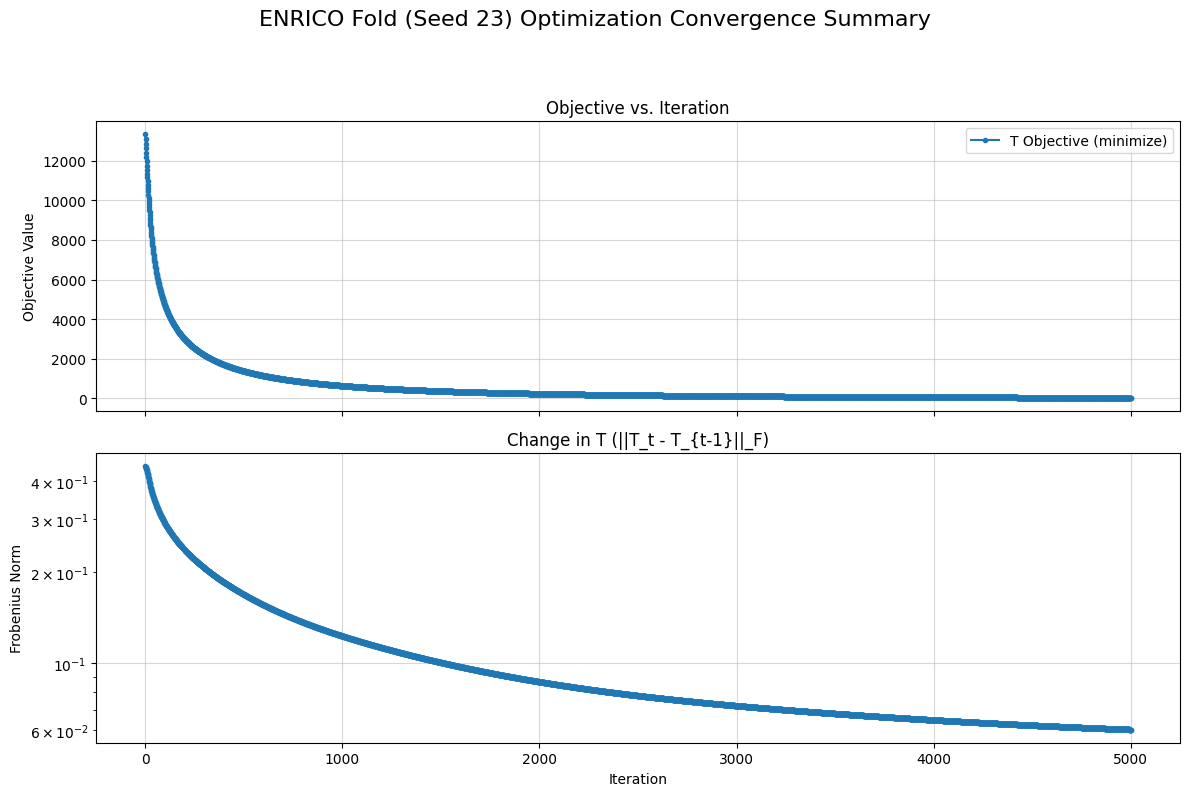

  ✓ Training completed for Fold 1

GradCA Training complete.

GradCA Training finished.


In [15]:
import torch
import numpy as np
import os
import gc
import pandas as pd  # Needed for monitor plots
import matplotlib.pyplot as plt  # Needed for monitor plots
from tqdm import tqdm  # Needed by monitor and optimizers

print("\n" + "="*20 + " Training GradCA " + "="*20)

# --- Hyperparameters for GradCA ---
gradca_hyperparams = {
    'eta_min': 1e-3,
    'max_iter': 5000,        # Number of outer iterations
    'num_steps_min': 1,      # T-update steps per iteration
    'initialization': 'zeros',
    'optimizers': 'adam',
}

fixed_params_gradca = {
    'tol': 1e-4,             # Convergence tolerance
    'seed': 23,
    'experiment': 'cmnist',
    'gain': 0.0,
}

# --- Select noise tensors (use fixed versions if available) ---
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

print(f"Using U_ll_hat_run with shape: {U_ll_hat_run.shape}")
print(f"Using U_hl_hat_run with shape: {U_hl_hat_run.shape}")

# --- Execute Training ---
results_gradca, monitors_gradca = train_gradca_single_run(
    cv_folds,
    U_ll_hat_run,
    U_hl_hat_run,
    det_ll_dict,
    det_hl_dict,
    omega,
    gradca_hyperparams,
    fixed_params_gradca,
)

print("\nGradCA Training finished.")

# Optional: free some memory after training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



==================== Training BaryCA ====================
Using U_ll_hat_run with shape: torch.Size([1000, 3072])
Using U_hl_hat_run with shape: torch.Size([1000, 64])
Starting BaryCA Training...
Hyperparameters: {'lr': 0.001, 'max_iter': 5000, 'tol': 0.0001}

--- Processing Fold 1/5 ---
Using device: cpu


BaryCA Optimization:   0%|          | 0/5000 [00:00<?, ?it/s]

Iter 0, Loss: 13321.690430


BaryCA Optimization:   4%|▍         | 208/5000 [00:05<01:55, 41.52it/s]

Iter 200, Loss: 2984.809082


...

Iter 4600, Loss: 40.712574


BaryCA Optimization:  96%|█████████▌| 4806/5000 [02:22<00:06, 27.74it/s]

Iter 4800, Loss: 36.033737


BaryCA Optimization: 100%|██████████| 5000/5000 [02:28<00:00, 33.60it/s]


Final BaryCA loss: 31.919191


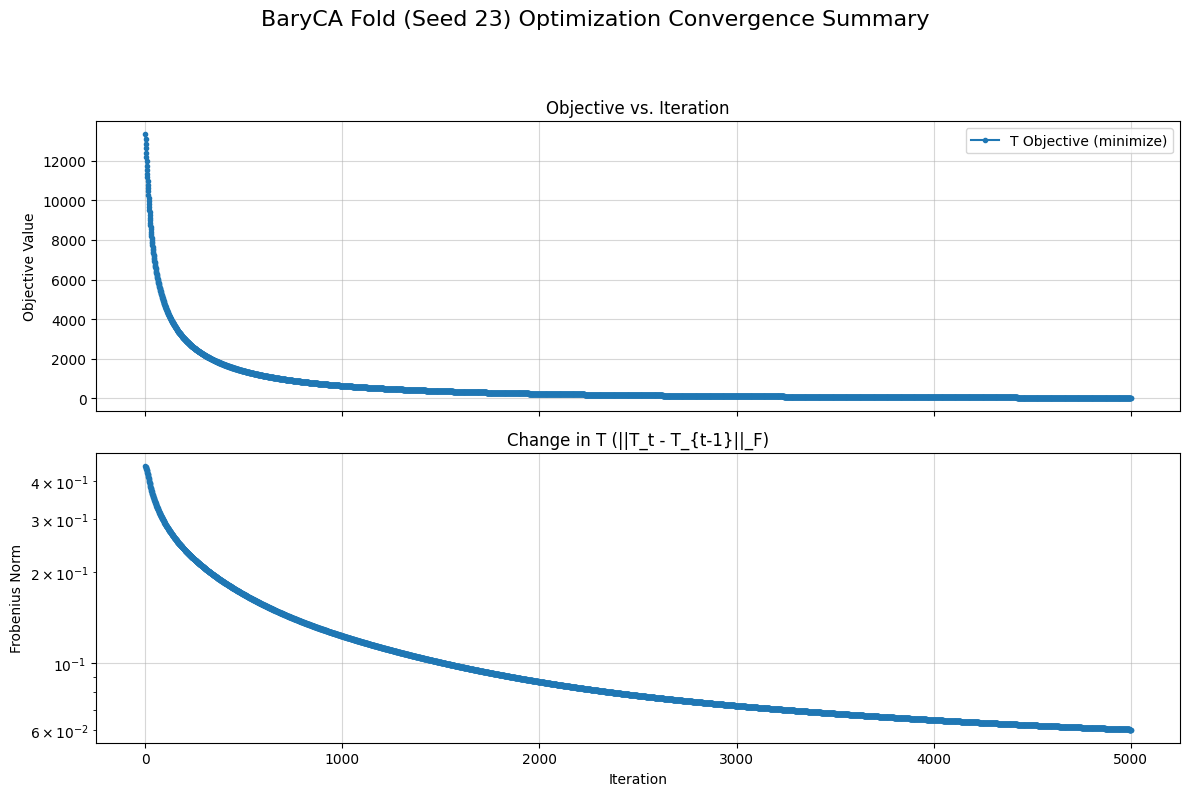

  ✓ Training completed for Fold 1

BaryCA Training complete.

BaryCA Training finished.


In [16]:
import torch
import numpy as np
import os
import gc
import pandas as pd  # Needed for monitor plots
import matplotlib.pyplot as plt  # Needed for monitor plots
from tqdm import tqdm  # Needed by monitor and optimizers

print("\n" + "="*20 + " Training BaryCA " + "="*20)

# --- Hyperparameters for BaryCA ---
baryca_hyperparams = {
    'lr': 1e-3,
    'max_iter': 5000,   # Number of outer iterations
    'tol': 1e-4,        # Convergence tolerance
}

fixed_params_baryca = {
    'seed': 23,
}

# --- Select noise tensors (use fixed versions if available) ---
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

print(f"Using U_ll_hat_run with shape: {U_ll_hat_run.shape}")
print(f"Using U_hl_hat_run with shape: {U_hl_hat_run.shape}")

# --- Execute Training ---
results_baryca, monitors_baryca = train_baryca_single_run(
    cv_folds,
    U_ll_hat_run,
    U_hl_hat_run,
    det_ll_dict,
    det_hl_dict,
    omega,
    baryca_hyperparams,
    fixed_params_baryca,
)

print("\nBaryCA Training finished.")

# Optional: free some memory after training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [17]:
import torch
import torch.nn.functional as F  # Needed for one-hot
import numpy as np
import os
import gc

print("\n" + "="*20 + " Training Abs-LiNGAM " + "="*20)

# --- Hyperparameters for Abs-LiNGAM ---
abslingam_hyperparams = {
    'tau_perfect': 1e-2,
    'tau_noisy': 1e-1,
}

tau_p = abslingam_hyperparams['tau_perfect']
tau_n = abslingam_hyperparams['tau_noisy']

# --- Find observational keys for LL and HL ---
dll_keys = list(Dll_samples.keys())
dhl_keys = list(Dhl_samples.keys())

if None in dll_keys:
    obs_key_ll = None
else:
    obs_key_ll = dll_keys[0]
    print(f"[Warning] Could not find explicit observational key for Dll_samples. Falling back to first key: {obs_key_ll}")

if None in dhl_keys:
    obs_key_hl = None
else:
    obs_key_hl = dhl_keys[0]
    print(f"[Warning] Could not find explicit observational key for Dhl_samples. Falling back to first key: {obs_key_hl}")

print(f"Observed LL key (Abs-LiNGAM): {obs_key_ll}")
print(f"Observed HL key (Abs-LiNGAM): {obs_key_hl}")

# --- Extract full observational data once ---
# Dll_samples[obs_key_ll] is a tuple: (final_images, img_shapes, digits, colors)
final_images_all = Dll_samples[obs_key_ll][0]   # (N, 3, 32, 32)
digits_all       = Dll_samples[obs_key_ll][2]   # (N,)
colors_all       = Dll_samples[obs_key_ll][3]   # (N,)

# Dhl_samples[obs_key_hl] is already the full HL vector (N, 21)
Dhl_obs_full_all = Dhl_samples[obs_key_hl]      # torch.Tensor (N, 21) or similar

print(f"final_images_all shape: {final_images_all.shape}")
print(f"digits_all shape: {digits_all.shape}")
print(f"colors_all shape: {colors_all.shape}")
print(f"Dhl_obs_full_all shape: {Dhl_obs_full_all.shape}")

# --- Execute training (per fold) ---
abslingam_training_results = {}

for i, fold_info in enumerate(cv_folds):
    fold_key = f'fold_{i}'
    print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
    train_indices, test_indices = fold_info['train'], fold_info['test']

    try:
        # Slice observational data for this fold
        final_images = final_images_all[train_indices]        # (N_train, 3, 32, 32)
        digits       = digits_all[train_indices]              # (N_train,)
        colors       = colors_all[train_indices]              # (N_train,)
        Dhl_obs_full = Dhl_obs_full_all[train_indices]        # (N_train, 21)

        # Reconstruct full LL vector: [pixels_flat, one_hot_digit, one_hot_color]
        images_flat   = final_images.view(final_images.shape[0], -1)       # (N_train, 3072)
        digits_onehot = F.one_hot(digits, num_classes=10).float()          # (N_train, 10)
        colors_onehot = F.one_hot(colors, num_classes=10).float()          # (N_train, 10)
        Dll_obs_full  = torch.cat([images_flat, digits_onehot, colors_onehot], dim=1)  # (N_train, 3092)

        # Run Abs-LiNGAM calculation (uses perfect_abstraction / noisy_abstraction defined earlier)
        abslingam_run_result = run_abs_lingam_cmnist(Dll_obs_full, Dhl_obs_full, tau_p, tau_n)

        abslingam_training_results[fold_key] = {}

        if abslingam_run_result['Perfect']['T'] is not None:
            abslingam_training_results[fold_key]['Abs-LiNGAM (Perfect)'] = {
                'T_matrix': torch.tensor(abslingam_run_result['Perfect']['T'], dtype=torch.float32),
                'test_indices': test_indices,
            }
        else:
            abslingam_training_results[fold_key]['Abs-LiNGAM (Perfect)'] = {
                'error': 'Calculation Failed'
            }

        if abslingam_run_result['Noisy']['T'] is not None:
            abslingam_training_results[fold_key]['Abs-LiNGAM (Noisy)'] = {
                'T_matrix': torch.tensor(abslingam_run_result['Noisy']['T'], dtype=torch.float32),
                'test_indices': test_indices,
            }
        else:
            abslingam_training_results[fold_key]['Abs-LiNGAM (Noisy)'] = {
                'error': 'Calculation Failed'
            }

        print(f"  ✓ Abs-LiNGAM completed for Fold {i+1}")

    except Exception as e:
        print(f"  ✗ ERROR during Abs-LiNGAM for Fold {i+1}: {e}")
        abslingam_training_results[fold_key] = {'error': str(e)}
        # you can choose to continue or break; I'll continue
        continue
    break
print("\nAbs-LiNGAM Training finished.")

# Wrap into the same structure as other methods
results_abslingam = {'abslingam': abslingam_training_results}

# Optional: cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



==================== Training Abs-LiNGAM ====================
[Warning] Could not find explicit observational key for Dll_samples. Falling back to first key: obs
[Warning] Could not find explicit observational key for Dhl_samples. Falling back to first key: obs
Observed LL key (Abs-LiNGAM): obs
Observed HL key (Abs-LiNGAM): obs
final_images_all shape: torch.Size([1000, 3, 32, 32])
digits_all shape: torch.Size([1000])
colors_all shape: torch.Size([1000])
Dhl_obs_full_all shape: torch.Size([1000, 84])

--- Processing Fold 1/5 ---
  ✓ Abs-LiNGAM completed for Fold 1

Abs-LiNGAM Training finished.


In [18]:
# --- Merge results from individual training runs ---
print("Merging results from all training runs...")

all_results = {}

# ================== DiRoCA (multiple radii) ==================
# all_results_diroca: {radius_key: {'diroca': {fold_key: ...}}}
if 'all_results_diroca' in locals() and isinstance(all_results_diroca, dict):
    for radius_key, results_outer in all_results_diroca.items():
        if results_outer is not None and isinstance(results_outer, dict) and 'diroca' in results_outer:
            method_name = f"diroca_{radius_key}"   # e.g. 'diroca_eps_5.0_delta_5.0'
            all_results[method_name] = results_outer['diroca']  # inner dict {fold_key: ...}
            print(f"  ✓ Added DiRoCA results for {radius_key}.")
        else:
            print(f"  ✗ Skipped DiRoCA results for {radius_key} (failed or invalid).")
else:
    print("  ✗ Warning: DiRoCA results ('all_results_diroca') not found or invalid.")

# ================== GradCA ==================
# results_gradca: {'gradca': {fold_key: ...}}
if 'results_gradca' in locals() and isinstance(results_gradca, dict) and 'gradca' in results_gradca:
    all_results['gradca'] = results_gradca['gradca']  # inner dict {fold_key: ...}
    print("  ✓ Added GradCA results (single run).")
else:
    print("  ✗ Warning: GradCA results not found or invalid.")

# ================== BaryCA ==================
# results_baryca: {'baryca': {fold_key: ...}}
if 'results_baryca' in locals() and isinstance(results_baryca, dict) and 'baryca' in results_baryca:
    all_results['baryca'] = results_baryca['baryca']  # inner dict {fold_key: ...}
    print("  ✓ Added BaryCA results (single run).")
else:
    print("  ✗ Warning: BaryCA results not found or invalid.")

# ================== Abs-LiNGAM ==================
# results_abslingam: {'abslingam': {fold_key: {'Abs-LiNGAM (Perfect)':..., 'Abs-LiNGAM (Noisy)':...}}}
if 'results_abslingam' in locals() and isinstance(results_abslingam, dict) and 'abslingam' in results_abslingam:
    all_results['abslingam'] = results_abslingam['abslingam']  # inner dict {fold_key: ...}
    print("  ✓ Added Abs-LiNGAM results (single run).")
else:
    print("  ✗ Warning: Abs-LiNGAM results not found or invalid.")


# ================== Summary / Sanity Check ==================
print("\nStructure of merged 'all_results':")
if not all_results:
    print("  'all_results' is empty. Cannot proceed with evaluation.")
else:
    for method_name, fold_dict in all_results.items():
        if isinstance(fold_dict, dict):
            valid_folds = sum(
                1 for fold_data in fold_dict.values()
                if isinstance(fold_data, dict) and 'error' not in fold_data
            )
            total_folds = len(fold_dict)
            print(f"  - {method_name}: Contains results for {valid_folds}/{total_folds} folds.")
            
            # Extra info for Abs-LiNGAM: show variants on first valid fold
            if method_name == 'abslingam' and valid_folds > 0:
                first_fold_key = list(fold_dict.keys())[0]
                first_fold_entry = fold_dict[first_fold_key]
                if isinstance(first_fold_entry, dict):
                    print(f"    (Contains Abs-LiNGAM variants: {list(first_fold_entry.keys())})")
        else:
            print(f"  - {method_name}: Entry is not a dictionary - invalid structure.")

print("\nMerging complete.")


Merging results from all training runs...
  ✓ Added DiRoCA results for eps_1.0_delta_0.0.
  ✓ Added DiRoCA results for eps_2.0_delta_0.0.
  ✓ Added DiRoCA results for eps_4.0_delta_0.0.
  ✓ Added DiRoCA results for eps_8.0_delta_0.0.
  ✓ Added GradCA results (single run).
  ✓ Added BaryCA results (single run).
  ✓ Added Abs-LiNGAM results (single run).

Structure of merged 'all_results':
  - diroca_eps_1.0_delta_0.0: Contains results for 1/1 folds.
  - diroca_eps_2.0_delta_0.0: Contains results for 1/1 folds.
  - diroca_eps_4.0_delta_0.0: Contains results for 1/1 folds.
  - diroca_eps_8.0_delta_0.0: Contains results for 1/1 folds.
  - gradca: Contains results for 1/1 folds.
  - baryca: Contains results for 1/1 folds.
  - abslingam: Contains results for 1/1 folds.
    (Contains Abs-LiNGAM variants: ['Abs-LiNGAM (Perfect)', 'Abs-LiNGAM (Noisy)'])

Merging complete.


In [19]:
print('opt after gym done!')

opt after gym done!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18741801..0.27199894].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07323819..0.07521024].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1586748..0.21122399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.065717615..0.05679988].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20866281..0.31836185].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.077244304..0.06287315].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got ran


==================== Visualizing Adversarial Perturbations (Fixed) ====================
Using DiRoCA results: diroca_eps_1.0_delta_0.0
Using run key: eps_1.0_delta_0.0


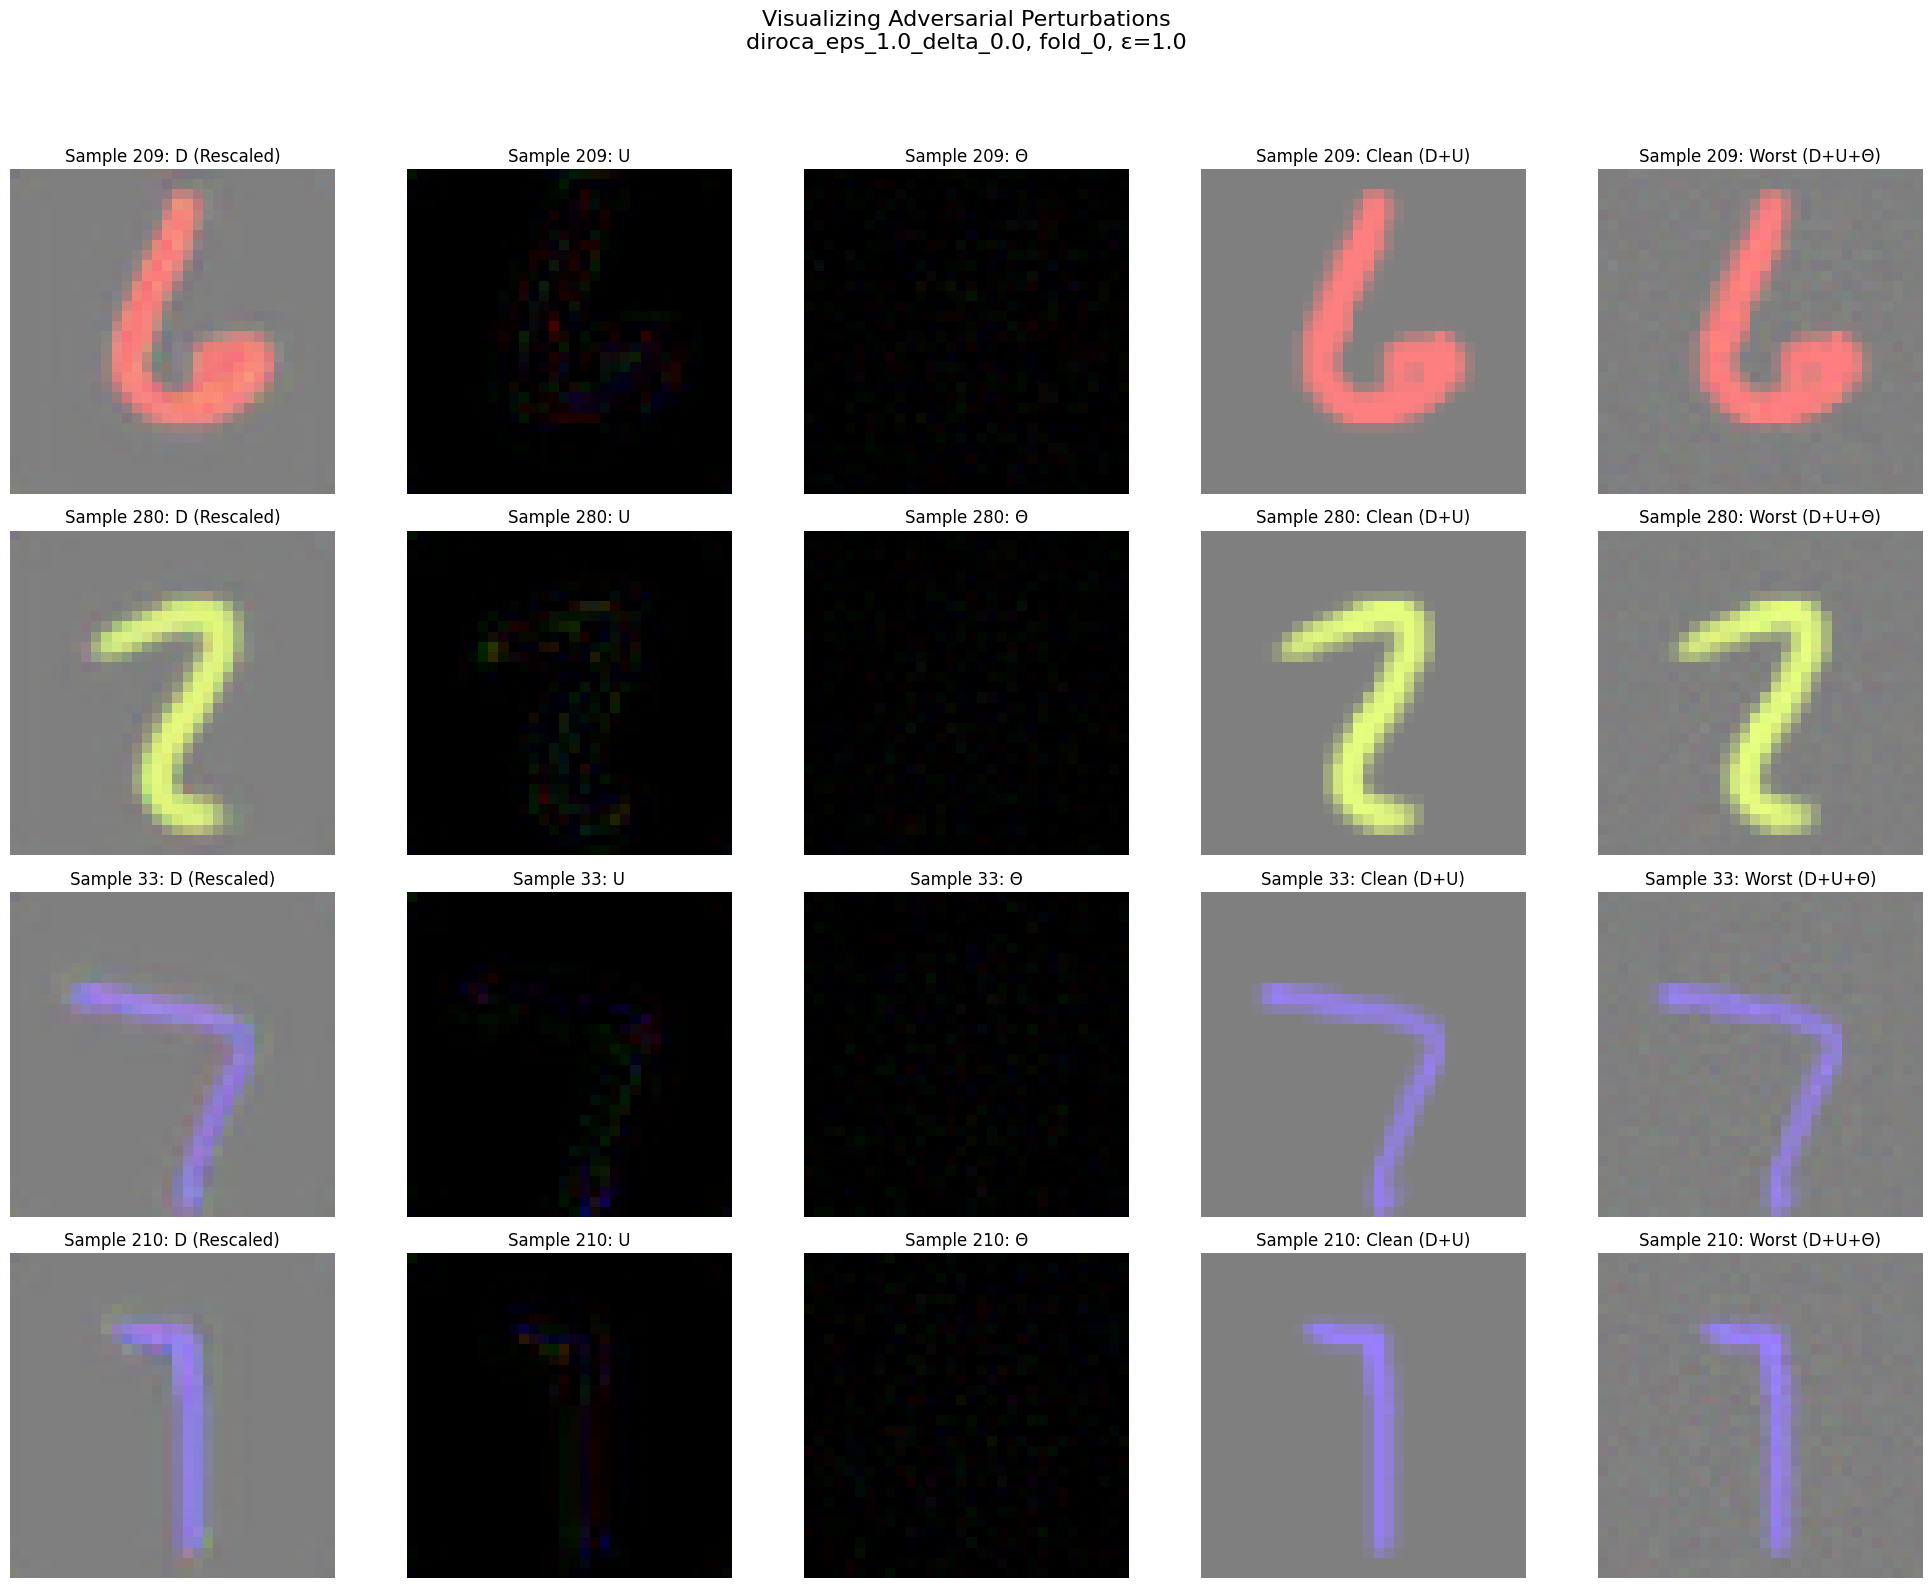

✓ Visualization completed successfully!


In [66]:
# --- Fixed Visualization Cell (CMNIST, new implementation) ---
import matplotlib.pyplot as plt
import torch
import numpy as np
import re

print("\n" + "="*20 + " Visualizing Adversarial Perturbations (Fixed) " + "="*20)

# --- 0. Helper: find observational LL key in det_ll_dict ---
def find_obs_ll_key(det_ll_dict):
    keys = list(det_ll_dict.keys())
    if not keys:
        raise ValueError("det_ll_dict is empty; cannot find observational key.")
    # Prefer explicit 'obs'-like keys
    for k in keys:
        # If key is a string like 'obs'
        if isinstance(k, str) and k.lower() in ["obs", "observational", "none", "null"]:
            return k
        # If key has a label attribute
        label = getattr(k, "label", None)
        if isinstance(label, str) and label.lower() in ["obs", "observational"]:
            return k
    # Fallback: first key
    print("[Warning] Could not find explicit observational key for det_ll_dict. Falling back to first key:", keys[0])
    return keys[0]

# --- 1. Select DiRoCA Run and Fold ---
fold_key_to_show = 'fold_0'
diroca_key_toplevel = next((k for k in all_results if k.startswith('diroca_eps_')), None)

if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found in all_results.")
else:
    print(f"Using DiRoCA results: {diroca_key_toplevel}")
    
    if fold_key_to_show not in all_results[diroca_key_toplevel]:
        print(f"Error: Fold {fold_key_to_show} not found in {diroca_key_toplevel}")
        run_result = None
    else:
        fold_data = all_results[diroca_key_toplevel][fold_key_to_show]
        
        # Find the inner run key like 'eps_5.0_delta_5.0'
        run_keys = [k for k in fold_data.keys() if k.startswith('eps_')]
        if not run_keys:
            print(f"Error: No run keys starting with 'eps_' found in fold data. Available keys: {list(fold_data.keys())}")
            run_result = None
        else:
            run_key = run_keys[0]
            run_result = fold_data[run_key]
            
            if isinstance(run_result, dict) and 'error' in run_result:
                print(f"Error in run result: {run_result['error']}")
                run_result = None
            else:
                print(f"Using run key: {run_key}")

    if run_result is not None:
        # --- 2. Extract adversarial Theta and basic info ---
        final_Theta_ll = run_result.get('final_Theta_ll')
        if final_Theta_ll is None:
            print("Theta (final_Theta_ll) not found in run_result.")
        else:
            if not isinstance(final_Theta_ll, torch.Tensor):
                final_Theta_ll = torch.tensor(final_Theta_ll, dtype=torch.float32)
            
            epsilon_run = run_result.get('epsilon', 'Unknown')
            fold_index = int(fold_key_to_show.split('_')[-1])
            train_indices = cv_folds[fold_index]['train']

            # --- 3. Get consistent noise tensor used in training ---
            # We trained with U_ll_hat_fixed if available, else flattened U_ll_hat
            if 'U_ll_hat_fixed' in locals():
                U_ll_base = U_ll_hat_fixed
            else:
                U_ll_tensor = torch.as_tensor(U_ll_hat, dtype=torch.float32)
                if U_ll_tensor.ndim > 2:
                    U_ll_base = U_ll_tensor.view(U_ll_tensor.shape[0], -1)
                else:
                    U_ll_base = U_ll_tensor

            U_ll_train = U_ll_base[train_indices]  # shape: (N_train, 3072)

            # --- 4. Get deterministic LL part for observational key ---
            obs_ll_key = find_obs_ll_key(det_ll_dict)
            det_ll_train_obs = det_ll_dict[obs_ll_key][train_indices]  # (N_train, 3092)

            # Split deterministic LL into pixels + labels
            det_pixels_train = det_ll_train_obs[:, :3072]     # (N_train, 3072)
            # label part (digits + colors) is not visualized, but kept for completeness
            # det_labels_train = det_ll_train_obs[:, 3072:]

            # Reconstruct pixels:
            #   Clean: D + U
            #   Worst-case: D + U + Theta
            clean_recon_pixels = det_pixels_train + U_ll_train
            worst_case_pixels = clean_recon_pixels + final_Theta_ll

            # --- 5. Select samples for visualization ---
            num_samples_to_show = 4
            N_train = U_ll_train.shape[0]
            if num_samples_to_show > N_train:
                num_samples_to_show = N_train

            np.random.seed(fold_index + 42)
            sample_indices = np.random.choice(N_train, num_samples_to_show, replace=False)

            # --- 6. Helper reshape functions ---
            def reshape_and_rescale_for_plot(pixel_vector_neg1_1):
                """
                Reshape vector of length 3072 into (32, 32, 3) and rescale
                from [-1, 1] to [0, 1] for imshow.
                """
                try:
                    if not isinstance(pixel_vector_neg1_1, torch.Tensor):
                        pixel_vector_neg1_1 = torch.tensor(pixel_vector_neg1_1)
                    pixel_vector_neg1_1 = pixel_vector_neg1_1.cpu()
                    
                    expected_elements = 3 * 32 * 32
                    if pixel_vector_neg1_1.numel() != expected_elements:
                        print(f"Warning: Unexpected numel {pixel_vector_neg1_1.numel()} in reshape. Expected {expected_elements}. Returning zeros.")
                        return np.zeros((32, 32, 3))
                    
                    img_chw = pixel_vector_neg1_1.view(3, 32, 32)
                    img_hwc = img_chw.permute(1, 2, 0)
                    img_np = img_hwc.numpy()
                    img_rescaled = (img_np + 1.0) / 2.0  # [-1,1] -> [0,1]
                    return np.clip(img_rescaled, 0.0, 1.0)
                except Exception as e:
                    print(f"Error in reshape_and_rescale_for_plot: {e}. Input shape: {pixel_vector_neg1_1.shape}")
                    return np.zeros((32, 32, 3))

            def reshape_for_plot(pixel_vector):
                """Reshape 3072-vector into (32, 32, 3) for noise / Theta viz."""
                try:
                    if not isinstance(pixel_vector, torch.Tensor):
                        pixel_vector = torch.tensor(pixel_vector)
                    pixel_vector = pixel_vector.cpu()
                    if pixel_vector.numel() != 3072:
                        return np.zeros((32, 32, 3))
                    img_chw = pixel_vector.view(3, 32, 32)
                    img_hwc = img_chw.permute(1, 2, 0)
                    return img_hwc.numpy()
                except Exception as e:
                    print(f"Error in reshape_for_plot: {e}")
                    return np.zeros((32, 32, 3))

            # --- 7. Plotting ---
            fig, axes = plt.subplots(num_samples_to_show, 5, figsize=(20, 4 * num_samples_to_show))
            if num_samples_to_show == 1:
                axes = np.array([axes])

            fig.suptitle(
                f'Visualizing Adversarial Perturbations\n'
                f'{diroca_key_toplevel}, {fold_key_to_show}, ε={epsilon_run}',
                fontsize=16,
                y=1.02
            )

            for row_i, idx in enumerate(sample_indices):
                # Col 1: Deterministic D (rescaled)
                ax = axes[row_i, 0]
                img = reshape_and_rescale_for_plot(det_pixels_train[idx])
                ax.imshow(img)
                ax.set_title(f'Sample {idx}: D (Rescaled)')
                ax.axis('off')

                # Col 2: Abduced Noise U (diverging map)
                ax = axes[row_i, 1]
                img_noise_vec = U_ll_train[idx]
                img = reshape_for_plot(img_noise_vec)
                norm = np.max(np.abs(img)) if img.size > 0 else 0.1
                ax.imshow(img, cmap='RdBu_r', vmin=-norm - 1e-6, vmax=norm + 1e-6)
                ax.set_title(f'Sample {idx}: U')
                ax.axis('off')

                # Col 3: Adversary Θ (diverging map)
                ax = axes[row_i, 2]
                img_pert_vec = final_Theta_ll[idx]
                img = reshape_for_plot(img_pert_vec)
                norm = np.max(np.abs(img)) if img.size > 0 else 0.1
                ax.imshow(img, cmap='RdBu_r', vmin=-norm - 1e-6, vmax=norm + 1e-6)
                ax.set_title(f'Sample {idx}: Θ')
                ax.axis('off')

                # Col 4: Clean Reconstructed D+U (rescaled)
                ax = axes[row_i, 3]
                img = reshape_and_rescale_for_plot(clean_recon_pixels[idx])
                ax.imshow(img)
                ax.set_title(f'Sample {idx}: Clean (D+U)')
                ax.axis('off')

                # Col 5: Worst-Case D+U+Θ (rescaled)
                ax = axes[row_i, 4]
                img = reshape_and_rescale_for_plot(worst_case_pixels[idx])
                ax.imshow(img)
                ax.set_title(f'Sample {idx}: Worst (D+U+Θ)')
                ax.axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.98])
            plt.show()

            print("✓ Visualization completed successfully!")

    else:
        print("✗ Could not access DiRoCA run_result for visualization.")


## Evaluation

In [67]:
import torch
import numpy as np

def apply_huber_contamination_cmnist(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
    """
    Contaminate ONLY the specified dimensions (columns) of clean_data with Gaussian noise.
    
    - clean_data: (N, D) tensor or array
    - alpha: fraction of samples to contaminate in (0,1]; if 1.0, all samples get noise
    - noise_scale: std of the Gaussian noise
    - noise_dims: slice / list / np.ndarray / torch.Tensor of column indices
    - loc: mean shift of the noise (0.0 = zero-mean)
    """
    # Quick early exit
    if alpha == 0 or noise_scale == 0:
        # Always return a tensor (clone so caller can modify safely)
        if isinstance(clean_data, torch.Tensor):
            return clean_data.clone().to(torch.float32)
        else:
            return torch.tensor(clean_data, dtype=torch.float32)

    # --- Convert input to tensor ---
    if isinstance(clean_data, torch.Tensor):
        data_tensor = clean_data.to(torch.float32)
    else:
        data_tensor = torch.tensor(clean_data, dtype=torch.float32)
    data_cont = data_tensor.clone()
    device = data_cont.device

    # --- Build index tensor for noise_dims ---
    # noise_dims can be a slice, list, np array, etc.
    if isinstance(noise_dims, slice):
        start = 0 if noise_dims.start is None else noise_dims.start
        stop  = data_cont.shape[1] if noise_dims.stop is None else noise_dims.stop
        step  = 1 if noise_dims.step is None else noise_dims.step
        noise_idx = torch.arange(start, stop, step, device=device)
    elif isinstance(noise_dims, (list, tuple, np.ndarray, torch.Tensor)):
        noise_idx = torch.as_tensor(noise_dims, dtype=torch.long, device=device)
    else:
        raise TypeError(f"Unsupported type for noise_dims: {type(noise_dims)}")

    # Nothing to do if no dims
    if noise_idx.numel() == 0:
        return data_cont

    # --- Extract sub-matrix to contaminate: (N, |noise_idx|) ---
    data_to_noise = data_cont.index_select(dim=1, index=noise_idx)

    # --- Sample Gaussian noise of same shape ---
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=loc, scale=noise_scale, size=tuple(data_to_noise.shape)).astype(np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=device)

    noisy_slice = data_to_noise + noise_tensor  # (N, |noise_idx|)

    n_samples = data_cont.shape[0]

    # --- Full contamination: all rows ---
    if alpha >= 1.0:
        # Replace all rows in those columns
        data_cont[:, noise_idx] = noisy_slice
        return data_cont

    # --- Partial contamination: subset of rows ---
    n_contaminate = int(alpha * n_samples)
    if n_contaminate == 0:
        return data_cont

    idx_to_contaminate_np = rng.choice(n_samples, size=n_contaminate, replace=False)
    idx_to_contaminate = torch.as_tensor(idx_to_contaminate_np, dtype=torch.long, device=device)

    # Use pure tensor indexing: first select rows, then columns
    data_cont.index_copy_(
        dim=0,
        index=idx_to_contaminate,
        source=data_cont.index_select(0, idx_to_contaminate).scatter(
            1,                                  # dim=1 (columns)
            noise_idx.view(1, -1).expand(n_contaminate, -1),
            noisy_slice.index_select(0, idx_to_contaminate)
        )
    )

    return data_cont

print("✅ Updated apply_huber_contamination_cmnist with robust indexing.")


✅ Updated apply_huber_contamination_cmnist with robust indexing.


In [68]:
def calculate_empirical_error_flat(T_matrix, Dll_test_flat, Dhl_test):
    """Abstraction error (Frobenius MSE) for linear T on flattened data."""
    try:
        T_matrix = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        Dll_test_flat = Dll_test_flat if isinstance(Dll_test_flat, torch.Tensor) else torch.tensor(Dll_test_flat, dtype=torch.float32)
        Dhl_test = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T_matrix = T_matrix.to(device)
        Dll_test_flat = Dll_test_flat.to(device)
        Dhl_test = Dhl_test.to(device)

        if T_matrix.shape[1] != Dll_test_flat.shape[1]:
            return float('inf')
        if T_matrix.shape[0] != Dhl_test.shape[1]:
            return float('inf')

        with torch.no_grad():
            Dhl_pred = Dll_test_flat @ T_matrix.T
            diff = Dhl_pred - Dhl_test
            err = torch.norm(diff, p='fro')**2 / max(1, diff.shape[0])
        return float(err.item())
    except Exception as e:
        print(f"Error in calculate_empirical_error_flat: {e}")
        return float('inf')


In [69]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc

# Assumed: cv_folds, omega, Dll_samples, Dhl_samples, all_results, output_dir

if 'output_dir' not in locals():
    output_dir = 'data/cmnist/results_empirical'
os.makedirs(output_dir, exist_ok=True)

print("\n--- Starting Evaluation: Clean & Huber-Noise (Cases 1 & 2) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5   # or whatever grid you like
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # 0 -> clean, 1 -> fully noisy

evaluation_records = []

# Count total configs for progress bar
total_methods_trained = 0
for method_group_key, method_data_inner in all_results.items():
    if isinstance(method_data_inner, dict):
        for fold_key, fold_data in method_data_inner.items():
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                total_methods_trained += len(fold_data)

total_configs = total_methods_trained * len(ALPHA_VALUES_TO_TEST) * N_TRIALS

if total_configs == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_eval = tqdm(total=total_configs, desc="Evaluating (clean + huber)")

    LL_PIXEL_DIMS = slice(0, 3072)  # flattened RGB (32*32*3)

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                # Human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                for alpha in ALPHA_VALUES_TO_TEST:
                    noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                    loc_ll = 0.0  # label-preserving pixel noise (mean 0)

                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images):
                                    continue

                                ll_images_test = ll_images[test_idx]
                                ll_digits_test = ll_digits[test_idx]
                                ll_colors_test = ll_colors[test_idx]
                                Dhl_test_clean = Dhl_samples[eta][test_idx]

                                seed = hash((fold_idx, run_key, float(alpha),
                                             float(noise_scale), trial, str(iota))) % (2**32)

                                # flatten images and contaminate only pixels
                                ll_images_test_flat = ll_images_test.view(ll_images_test.shape[0], -1)
                                ll_images_cont_flat = apply_huber_contamination_cmnist(
                                    ll_images_test_flat, alpha, noise_scale,
                                    noise_dims=LL_PIXEL_DIMS, seed=seed, loc=loc_ll
                                )

                                # one-hot digits & colors (never contaminated)
                                ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()

                                device = ll_images_cont_flat.device
                                Dll_test_cont_flat_full = torch.cat(
                                    [ll_images_cont_flat,
                                     ll_digits_onehot.to(device),
                                     ll_colors_onehot.to(device)],
                                    dim=1
                                )

                                # High-level stays clean (label-preserving)
                                Dhl_test = Dhl_test_clean.to(device)

                                error = calculate_empirical_error_flat(
                                    T_matrix, Dll_test_cont_flat_full, Dhl_test
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"ERROR inner loop: {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha}, N{noise_scale}, "
                                      f"T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'huber_noise',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha),
                            'noise_scale': float(noise_scale),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta'] = run_result.get('delta', np.nan)

                        evaluation_records.append(record)
                        pbar_eval.update(1)

                        # cleanup
                        del (ll_images_test, ll_digits_test, ll_colors_test,
                             Dhl_test_clean, ll_images_test_flat, ll_images_cont_flat,
                             ll_digits_onehot, ll_colors_onehot, Dll_test_cont_flat_full)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_eval.close()

    full_results_df = pd.DataFrame(evaluation_records)
    eval_output_path = os.path.join(output_dir, "cmnist_eval_clean_and_huber.pkl")
    full_results_df.to_pickle(eval_output_path)
    print(f"\nEvaluation results saved to {eval_output_path}")



--- Starting Evaluation: Clean & Huber-Noise (Cases 1 & 2) ---


Evaluating (clean + huber): 100%|██████████| 80/80 [00:04<00:00, 19.37it/s]


Evaluation results saved to data/cmnist/results_empirical/cmnist_eval_clean_and_huber.pkl


In [70]:
import numpy as np
import torchvision.transforms as T

def apply_camera_shifts_cmnist(images, alpha, transform, seed=None):
    """
    Apply a camera/augmentation transform to a fraction alpha of images.

    images   : (N, C, H, W) tensor
    alpha    : fraction of samples to augment (0 -> none, 1 -> all)
    transform: torchvision transform that maps a single image tensor -> tensor
    """
    if alpha <= 0.0:
        return images

    images_aug = images.clone()
    N = images.shape[0]
    rng = np.random.default_rng(seed)
    n_aug = int(alpha * N)
    if n_aug == 0:
        return images

    idx_all = np.arange(N)
    idx_aug = rng.choice(idx_all, size=n_aug, replace=False)

    for j in idx_aug:
        # transform expects (C,H,W) tensor
        images_aug[j] = transform(images_aug[j])

    return images_aug


In [71]:
camera_transform = T.Compose([
    T.RandomAffine(
        degrees=10,              # small rotation
        translate=(0.1, 0.1),    # small translation
        scale=(0.9, 1.1)         # mild zoom
    ),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    # optionally: T.GaussianBlur(3, sigma=(0.1, 1.0)),
])


In [72]:
print("\n--- Starting Evaluation: Camera/Augmentation Shifts (Case 3) ---")

N_TRIALS = 5
ALPHA_VALUES_CAMERA = [0.0, 1.0]  # 0 -> clean, 1 -> all images augmented

eval_records_camera = []

if total_methods_trained == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_cam = tqdm(
        total=total_methods_trained * len(ALPHA_VALUES_CAMERA) * N_TRIALS,
        desc="Evaluating (camera shifts)"
    )

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                for alpha_cam in ALPHA_VALUES_CAMERA:
                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images):
                                    continue

                                ll_images_test = ll_images[test_idx]          # (N,C,H,W)
                                ll_digits_test = ll_digits[test_idx]
                                ll_colors_test = ll_colors[test_idx]
                                Dhl_test_clean = Dhl_samples[eta][test_idx]

                                seed = hash((fold_idx, run_key, float(alpha_cam),
                                             trial, str(iota))) % (2**32)

                                # apply camera/augmentation shift
                                ll_images_shifted = apply_camera_shifts_cmnist(
                                    ll_images_test, alpha_cam, camera_transform, seed=seed
                                )

                                # flatten and append one-hot codes
                                ll_images_shifted_flat = ll_images_shifted.view(ll_images_shifted.shape[0], -1)
                                ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()

                                device = ll_images_shifted_flat.device
                                Dll_test_flat_full = torch.cat(
                                    [ll_images_shifted_flat,
                                     ll_digits_onehot.to(device),
                                     ll_colors_onehot.to(device)],
                                    dim=1
                                )
                                Dhl_test = Dhl_test_clean.to(device)

                                error = calculate_empirical_error_flat(
                                    T_matrix, Dll_test_flat_full, Dhl_test
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"ERROR (camera) inner loop: {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha_cam}, T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'camera_aug',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha_cam),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta'] = run_result.get('delta', np.nan)

                        eval_records_camera.append(record)
                        pbar_cam.update(1)

                        # cleanup
                        del (ll_images_test, ll_digits_test, ll_colors_test,
                             Dhl_test_clean, ll_images_shifted, ll_images_shifted_flat,
                             ll_digits_onehot, ll_colors_onehot, Dll_test_flat_full)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_cam.close()

    df_cam = pd.DataFrame(eval_records_camera)
    cam_output_path = os.path.join(output_dir, "cmnist_eval_camera_shifts.pkl")
    df_cam.to_pickle(cam_output_path)
    print(f"\nCamera-shift evaluation results saved to {cam_output_path}")



--- Starting Evaluation: Camera/Augmentation Shifts (Case 3) ---


Evaluating (camera shifts): 100%|██████████| 80/80 [00:23<00:00,  3.37it/s]


Camera-shift evaluation results saved to data/cmnist/results_empirical/cmnist_eval_camera_shifts.pkl


In [73]:
df_clean = df_huber[(df_huber['shift_type'] == 'huber_noise') &
                    (df_huber['alpha'].abs() < 1e-8)]

summary_clean = (df_clean
                 .groupby('method')['error']
                 .agg(['mean', 'std'])
                 .sort_values('mean'))
print("\n--- Clean (alpha=0) ---")
print(summary_clean)



--- Clean (alpha=0) ---
                                   mean  std
method                                      
Abs-LiNGAM (Perfect)          48.326234  0.0
Abs-LiNGAM (Noisy)           328.636093  0.0
DiRoCA (eps_4.0_delta_4.0)  5009.819580  0.0
DiRoCA (eps_2.0_delta_2.0)  5013.582129  0.0
DiRoCA (eps_8.0_delta_8.0)  5033.354199  0.0
DiRoCA (eps_1.0_delta_1.0)  5042.612744  0.0
BaryCA                      8572.621240  0.0
GradCA                      8572.628418  0.0


In [74]:
df_noisy = df_huber[(df_huber['shift_type'] == 'huber_noise') &
                    (df_huber['alpha'].round(3) == 1.0)]

summary_noisy = (df_noisy
                 .groupby('method')['error']
                 .agg(['mean', 'std'])
                 .sort_values('mean'))
print("\n--- Huber noise (alpha=1) ---")
print(summary_noisy)



--- Huber noise (alpha=1) ---
                                    mean         std
method                                              
Abs-LiNGAM (Perfect)          357.948286    5.448206
Abs-LiNGAM (Noisy)            360.355906    1.055341
DiRoCA (eps_4.0_delta_4.0)  68240.370469  271.001064
DiRoCA (eps_2.0_delta_2.0)  68349.719063  371.189134
DiRoCA (eps_8.0_delta_8.0)  68450.832344  285.565445
DiRoCA (eps_1.0_delta_1.0)  68494.033281  266.138730
BaryCA                      72565.600625  380.944741
GradCA                      72630.688281  240.182948


In [53]:
df_cam_clean = df_cam[(df_cam['shift_type'] == 'camera_aug') &
                      (df_cam['alpha'].abs() < 1e-8)]

df_cam_shift = df_cam[(df_cam['shift_type'] == 'camera_aug') &
                      (df_cam['alpha'].round(3) == 1.0)]

summary_cam_clean = (df_cam_clean.groupby('method')['error']
                     .agg(['mean', 'std']).sort_values('mean'))
summary_cam_shift = (df_cam_shift.groupby('method')['error']
                     .agg(['mean', 'std']).sort_values('mean'))

print("\n--- Camera (clean, alpha=0) ---")
print(summary_cam_clean)

print("\n--- Camera (all shifted, alpha=1) ---")
print(summary_cam_shift)



--- Camera (clean, alpha=0) ---
                                   mean  std
method                                      
Abs-LiNGAM (Perfect)          48.326234  0.0
Abs-LiNGAM (Noisy)           328.636093  0.0
BaryCA                      2221.548413  0.0
GradCA                      4645.704272  0.0
DiRoCA (eps_4.0_delta_0.0)  5010.211328  0.0
DiRoCA (eps_2.0_delta_0.0)  5014.034717  0.0
DiRoCA (eps_8.0_delta_0.0)  5033.354199  0.0
DiRoCA (eps_1.0_delta_0.0)  5043.177148  0.0

--- Camera (all shifted, alpha=1) ---
                                   mean         std
method                                             
Abs-LiNGAM (Perfect)          98.596340    1.600089
Abs-LiNGAM (Noisy)           331.656260    0.344614
BaryCA                      3232.625571   21.300219
GradCA                      5139.667314   22.395699
DiRoCA (eps_8.0_delta_0.0)  5477.094707   25.563461
DiRoCA (eps_1.0_delta_0.0)  5483.410713   44.948678
DiRoCA (eps_2.0_delta_0.0)  5501.588779   17.507400
DiRoCA (ep

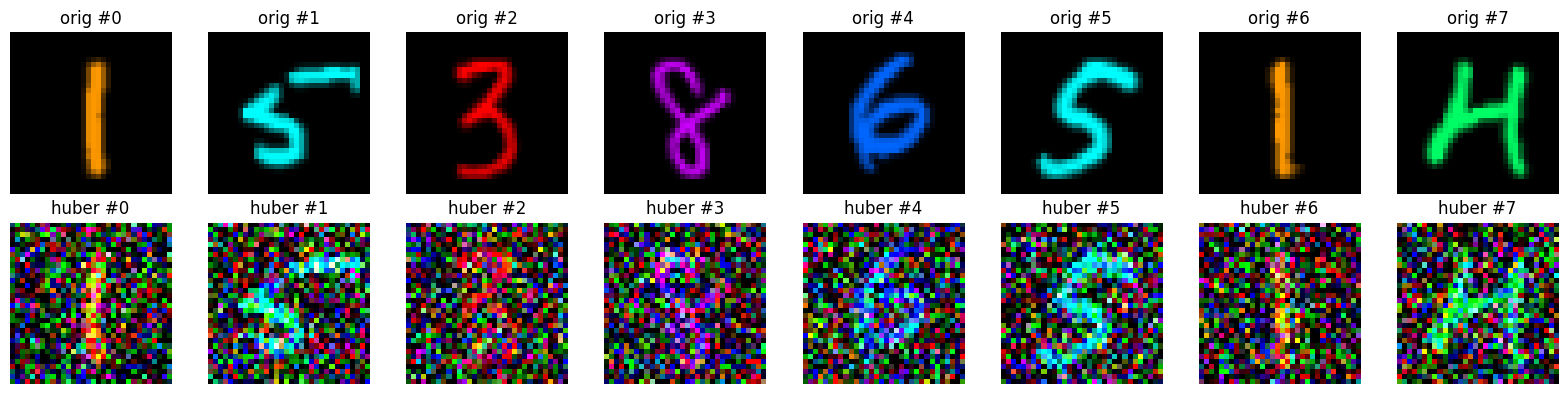

In [75]:
import torch
import matplotlib.pyplot as plt

# pick one environment
iota = list(Dll_samples.keys())[0]
ll_images, _, ll_digits, ll_colors = Dll_samples[iota]

# pick some indices
idx = torch.arange(16)  # first 16 examples
imgs = ll_images[idx]   # (16, C, H, W)

# flatten for Huber
imgs_flat = imgs.view(imgs.shape[0], -1)

d = imgs_flat.shape[1]
imgs_huber_flat = apply_huber_contamination_cmnist(
    imgs_flat,
    alpha=1.0,
    noise_scale=0.5,
    noise_dims=slice(0, d),   # or np.arange(d)
    seed=0,
    loc=0.0
)


imgs_huber = imgs_huber_flat.view_as(imgs)  # back to (N,C,H,W)

# plot original vs huber
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))

for j in range(n_show):
    # original
    ax = axes[0, j]
    img = imgs[j].detach().cpu()
    # if CMNIST is 3-channel RGB, permute to (H,W,C)
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"orig #{j}")

    # huber
    ax = axes[1, j]
    img_h = imgs_huber[j].detach().cpu()
    ax.imshow(img_h.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"huber #{j}")

plt.tight_layout()
plt.show()


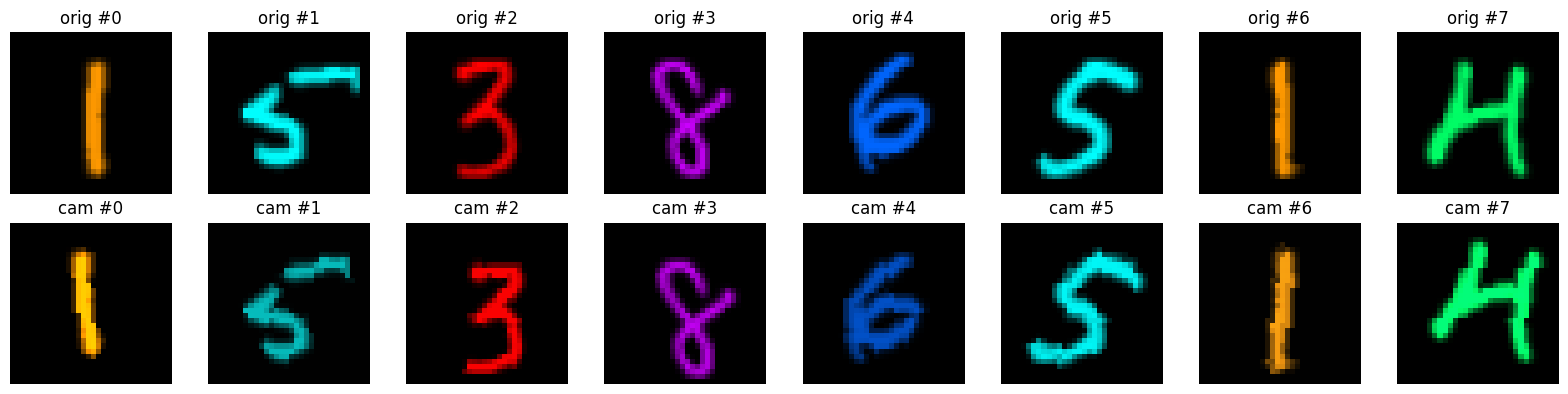

In [76]:
# reuse same subset imgs = ll_images[idx]

imgs_cam = apply_camera_shifts_cmnist(
    imgs,
    alpha=1.0,              # apply to all 16
    transform=camera_transform,
    seed=0
)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))

for j in range(n_show):
    # original
    ax = axes[0, j]
    img = imgs[j].detach().cpu()
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"orig #{j}")

    # camera-shifted
    ax = axes[1, j]
    img_c = imgs_cam[j].detach().cpu()
    ax.imshow(img_c.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"cam #{j}")

plt.tight_layout()
plt.show()


In [57]:
import torch
import pandas as pd
import numpy as np

records = []

for method_group_key, folds in all_results.items():
    if not isinstance(folds, dict):
        continue

    for fold_key, fold_data in folds.items():
        if not fold_key.startswith("fold_"):
            continue
        if not isinstance(fold_data, dict) or "error" in fold_data:
            continue  # skip failed folds

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if not isinstance(run_result, dict):
                continue
            if "error" in run_result or run_result.get("T_matrix") is None:
                continue

            T = run_result["T_matrix"]
            T = T if isinstance(T, torch.Tensor) else torch.tensor(T, dtype=torch.float32)

            # method name logic (same as in your eval)
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            # spectral & Frobenius norms
            with torch.no_grad():
                fro_norm = torch.linalg.norm(T, ord='fro').item()
                try:
                    spec_norm = torch.linalg.norm(T, ord=2).item()
                except RuntimeError:
                    # fallback if 2-norm fails for any reason
                    spec_norm = float("nan")

            # optimization params (to see actual eps/delta used)
            opt_params = run_result.get("optimization_params", {})
            eps_train  = opt_params.get("epsilon", np.nan)
            delta_train = opt_params.get("delta", np.nan)

            records.append({
                "method_group": method_group_key,
                "run_key": run_key,
                "fold": fold_idx,
                "method": method_name,
                "fro_norm": fro_norm,
                "spec_norm": spec_norm,
                "epsilon_train": float(eps_train),
                "delta_train": float(delta_train),
            })

norm_df = pd.DataFrame(records)

print("\n=== Per-run norms and training radii (first 50 rows) ===")
print(norm_df.head(50))

print("\n=== Aggregated by method (mean ± std) ===")
summary = norm_df.groupby("method")[["fro_norm", "spec_norm", "epsilon_train", "delta_train"]].agg(["mean", "std"])
print(summary)



=== Per-run norms and training radii (first 50 rows) ===
               method_group               run_key  fold  \
0  diroca_eps_1.0_delta_0.0     eps_1.0_delta_0.0     0   
1  diroca_eps_2.0_delta_0.0     eps_2.0_delta_0.0     0   
2  diroca_eps_4.0_delta_0.0     eps_4.0_delta_0.0     0   
3  diroca_eps_8.0_delta_0.0     eps_8.0_delta_0.0     0   
4                    gradca            gradca_run     0   
5                    baryca            baryca_run     0   
6                 abslingam  Abs-LiNGAM (Perfect)     0   
7                 abslingam    Abs-LiNGAM (Noisy)     0   

                       method    fro_norm  spec_norm  epsilon_train  \
0  DiRoCA (eps_1.0_delta_0.0)  505.305847  64.014465            NaN   
1  DiRoCA (eps_2.0_delta_0.0)  505.057465  63.968273            NaN   
2  DiRoCA (eps_4.0_delta_0.0)  504.842468  63.929390            NaN   
3  DiRoCA (eps_8.0_delta_0.0)  504.163879  63.821411            NaN   
4                      GradCA  507.028625  64.257736   

In [22]:
import torch
import numpy as np

print("\n" + "="*20 + " T-matrix Overview " + "="*20)

for method_group_key, fold_dict in all_results.items():
    if not isinstance(fold_dict, dict):
        continue
    
    print(f"\nMethod group: {method_group_key}")
    for fold_key, fold_data in fold_dict.items():
        if not isinstance(fold_data, dict) or 'error' in fold_data:
            continue
        
        print(f"  Fold: {fold_key}")
        for run_key, run_result in fold_data.items():
            if not isinstance(run_result, dict):
                continue
            T_matrix = run_result.get('T_matrix', None)
            if T_matrix is None:
                continue
            T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix)
            shape = tuple(T.shape)
            fro_norm = torch.norm(T, p='fro').item()
            print(f"    Run: {run_key:25s}  shape={shape}, ||T||_F={fro_norm:.3e}")



==================== T-matrix Overview ====================

Method group: diroca_eps_1.0_delta_1.0
  Fold: fold_0
    Run: eps_1.0_delta_1.0          shape=(84, 3092), ||T||_F=5.053e+02

Method group: diroca_eps_2.0_delta_2.0
  Fold: fold_0
    Run: eps_2.0_delta_2.0          shape=(84, 3092), ||T||_F=5.051e+02

Method group: diroca_eps_4.0_delta_4.0
  Fold: fold_0
    Run: eps_4.0_delta_4.0          shape=(84, 3092), ||T||_F=5.048e+02

Method group: diroca_eps_8.0_delta_8.0
  Fold: fold_0
    Run: eps_8.0_delta_8.0          shape=(84, 3092), ||T||_F=5.042e+02

Method group: gradca
  Fold: fold_0
    Run: gradca_run                 shape=(84, 3092), ||T||_F=5.085e+02

Method group: baryca
  Fold: fold_0
    Run: baryca_run                 shape=(84, 3092), ||T||_F=5.085e+02

Method group: abslingam
  Fold: fold_0
    Run: Abs-LiNGAM (Perfect)       shape=(84, 3092), ||T||_F=4.292e+01
    Run: Abs-LiNGAM (Noisy)         shape=(84, 3092), ||T||_F=1.379e+01


In [23]:
import numpy as np
import torch

print("\n" + "="*20 + " DiRoCA Perturbation Check " + "="*20)

# pick first diroca key
diroca_key = next((k for k in all_results if k.startswith('diroca_eps_')), None)
fold_key = 'fold_0'

if diroca_key is None or fold_key not in all_results[diroca_key]:
    print("No DiRoCA or fold_0 found.")
else:
    fold_data = all_results[diroca_key][fold_key]
    run_keys = [k for k in fold_data.keys() if k.startswith('eps_')]
    if not run_keys:
        print("No DiRoCA run keys found in fold_0.")
    else:
        run_key = run_keys[0]
        run_result = fold_data[run_key]
        Theta_np = run_result.get('final_Theta_ll', None)
        Phi_np   = run_result.get('final_Phi_hl', None)
        eps      = run_result.get('epsilon', np.nan)
        delt     = run_result.get('delta', np.nan)
        
        if Theta_np is None or Phi_np is None:
            print("Theta or Phi not stored in run_result.")
        else:
            Theta = torch.tensor(Theta_np, dtype=torch.float32)
            Phi   = torch.tensor(Phi_np, dtype=torch.float32)
            N = Theta.shape[0]
            theta_norm = torch.norm(Theta, p='fro').item()
            phi_norm   = torch.norm(Phi, p='fro').item()
            theta_bound = eps * np.sqrt(N)
            phi_bound   = delt * np.sqrt(N)

            print(f"Using DiRoCA run: {diroca_key} / {run_key}")
            print(f"  N = {N}")
            print(f"  epsilon = {eps},  delta = {delt}")
            print(f"  ||Theta||_F = {theta_norm:.3f},  bound = {theta_bound:.3f}")
            print(f"  ||Phi||_F   = {phi_norm:.3f},  bound = {phi_bound:.3f}")



==================== DiRoCA Perturbation Check ====================
Using DiRoCA run: diroca_eps_1.0_delta_1.0 / eps_1.0_delta_1.0
  N = 400
  epsilon = 1.0,  delta = 1.0
  ||Theta||_F = 20.000,  bound = 20.000
  ||Phi||_F   = 20.000,  bound = 20.000


In [24]:
import os
import pandas as pd
import numpy as np

eval_path = os.path.join(output_dir, "all_methods_evaluation_results.pkl")
print(f"Loading evaluation from: {eval_path}")
df = pd.read_pickle(eval_path)

print("\nHead of evaluation dataframe:")
print(df.head())

print("\nUnique methods:", sorted(df['method'].unique()))
print("Unique alphas:", sorted(df['alpha'].unique()))
print("Unique noise_scales:", sorted(df['noise_scale'].unique()))


Loading evaluation from: data/cmnist/results_empirical/all_methods_evaluation_results.pkl

Head of evaluation dataframe:
                       method  fold  alpha  noise_scale  trial  error  \
0  DiRoCA (eps_1.0_delta_1.0)     0    0.0          0.0      0    NaN   
1  DiRoCA (eps_1.0_delta_1.0)     0    0.0          0.0      1    NaN   
2  DiRoCA (eps_1.0_delta_1.0)     0    0.0          0.0      2    NaN   
3  DiRoCA (eps_1.0_delta_1.0)     0    0.0          0.0      3    NaN   
4  DiRoCA (eps_1.0_delta_1.0)     0    0.0          0.0      4    NaN   

   train_epsilon  train_delta  
0            1.0          1.0  
1            1.0          1.0  
2            1.0          1.0  
3            1.0          1.0  
4            1.0          1.0  

Unique methods: ['Abs-LiNGAM (Noisy)', 'Abs-LiNGAM (Perfect)', 'BaryCA', 'DiRoCA (eps_1.0_delta_1.0)', 'DiRoCA (eps_2.0_delta_2.0)', 'DiRoCA (eps_4.0_delta_4.0)', 'DiRoCA (eps_8.0_delta_8.0)', 'GradCA']
Unique alphas: [0.0, 1.0]
Unique noise_scale

In [25]:
alpha_clean = 0.0
alpha_noisy = 1.0

print("\n--- Clean (alpha=0.0) ---")
clean = df[np.isclose(df['alpha'], alpha_clean)]
print(clean.groupby('method')['error'].agg(['mean', 'std', 'count']).sort_values('mean'))

print(f"\n--- Noisy (alpha={alpha_noisy}, sigma={NOISE_SCALE_FOR_ALPHA1}) ---")
noisy = df[np.isclose(df['alpha'], alpha_noisy)]
print(noisy.groupby('method')['error'].agg(['mean', 'std', 'count']).sort_values('mean'))



--- Clean (alpha=0.0) ---
                            mean  std  count
method                                      
Abs-LiNGAM (Noisy)           NaN  NaN      0
Abs-LiNGAM (Perfect)         NaN  NaN      0
BaryCA                       NaN  NaN      0
DiRoCA (eps_1.0_delta_1.0)   NaN  NaN      0
DiRoCA (eps_2.0_delta_2.0)   NaN  NaN      0
DiRoCA (eps_4.0_delta_4.0)   NaN  NaN      0
DiRoCA (eps_8.0_delta_8.0)   NaN  NaN      0
GradCA                       NaN  NaN      0

--- Noisy (alpha=1.0, sigma=0.5) ---
                            mean  std  count
method                                      
Abs-LiNGAM (Noisy)           NaN  NaN      0
Abs-LiNGAM (Perfect)         NaN  NaN      0
BaryCA                       NaN  NaN      0
DiRoCA (eps_1.0_delta_1.0)   NaN  NaN      0
DiRoCA (eps_2.0_delta_2.0)   NaN  NaN      0
DiRoCA (eps_4.0_delta_4.0)   NaN  NaN      0
DiRoCA (eps_8.0_delta_8.0)   NaN  NaN      0
GradCA                       NaN  NaN      0


In [26]:
import torch
import numpy as np
import torch.nn.functional as F

def quick_test_abslingam(T_matrix, ll_images, ll_digits, ll_colors, hl_targets):
    T = torch.tensor(T_matrix).float()
    X = ll_images.view(ll_images.shape[0], -1).float()
    X = torch.cat([
        X, 
        F.one_hot(ll_digits, num_classes=10).float(),
        F.one_hot(ll_colors, num_classes=10).float()
    ], dim=1)
    Y = hl_targets.float()

    pred = X @ T.T
    err = torch.norm(pred - Y, p='fro')**2 / Y.shape[0]
    return err.item()

# pick abslingam perfect
A = all_results['abslingam']['fold_0']['Abs-LiNGAM (Perfect)']
T_abs = A['T_matrix']
idx = A['test_indices']

# extract data
iota = 'obs'  # pick a valid key
ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
hl = Dhl_samples[omega[iota]]

# mild noise:
alpha = 1.0
sigma = 0.1
seed = 123

rng = np.random.default_rng(seed)
flat = ll_images.view(ll_images.shape[0], -1)
noise = rng.normal(0, sigma, size=flat.shape).astype(np.float32)
flat_noisy = flat + torch.tensor(noise)

# reassemble full ll vector
Xnoisy = torch.cat([
    flat_noisy,
    F.one_hot(ll_digits, num_classes=10).float(),
    F.one_hot(ll_colors, num_classes=10).float()
], dim=1)

# evaluate
try:
    err = quick_test_abslingam(T_abs, ll_images[idx], ll_digits[idx], ll_colors[idx], hl[idx])
    print("Abs-LiNGAM error on mild noise:", err)
except Exception as e:
    print("Failed:", e)


Abs-LiNGAM error on mild noise: 42.26823425292969


/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_18628/4261375998.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T = torch.tensor(T_matrix).float()


In [27]:
import torch
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm

def eval_abslingam_simple(T_matrix, Dll_samples, Dhl_samples, omega, cv_folds,
                          method_name="Abs-LiNGAM (Perfect)",
                          alpha_values=(0.0, 1.0),
                          noise_scale=0.5,
                          n_trials=5):

    results = []
    T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)

    # Pick the fold and run we have (fold_0)
    fold_idx = 0
    test_idx = cv_folds[fold_idx]['test']

    # Use obs env for simplicity
    iota_obs = 'obs'
    eta_obs = omega[iota_obs]

    ll_images, _, ll_digits, ll_colors = Dll_samples[iota_obs]
    hl_full = Dhl_samples[eta_obs]

    # Restrict to test split
    ll_images = ll_images[test_idx]
    ll_digits = ll_digits[test_idx]
    ll_colors = ll_colors[test_idx]
    hl_full   = hl_full[test_idx]

    # Full LL vector (no contamination yet)
    ll_flat = ll_images.view(ll_images.shape[0], -1).float()
    ll_dig_oh = F.one_hot(ll_digits, num_classes=10).float()
    ll_col_oh = F.one_hot(ll_colors, num_classes=10).float()
    Dll_full_clean = torch.cat([ll_flat, ll_dig_oh, ll_col_oh], dim=1)  # (N, 3092)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    T = T.to(device)
    Dll_full_clean = Dll_full_clean.to(device)
    hl_full = hl_full.to(device)

    for alpha in alpha_values:
        for trial in range(n_trials):
            if np.isclose(alpha, 0.0):
                # clean
                X = Dll_full_clean
                Y = hl_full
            else:
                # noisy: contaminate LL pixels and HL features with zero-mean noise
                rng = np.random.default_rng(seed=hash((method_name, alpha, noise_scale, trial)) % (2**32))

                # LL noise on pixels only
                noise_ll = rng.normal(0.0, noise_scale, size=ll_flat.shape).astype(np.float32)
                ll_flat_noisy = ll_flat + torch.tensor(noise_ll, device=device)

                X = torch.cat([ll_flat_noisy, ll_dig_oh.to(device), ll_col_oh.to(device)], dim=1)

                # HL noise only on feature dims (20:)
                hl_labels = hl_full[:, :20]
                hl_feats  = hl_full[:, 20:]
                noise_hl  = rng.normal(0.0, noise_scale, size=hl_feats.shape).astype(np.float32)
                hl_feats_noisy = hl_feats + torch.tensor(noise_hl, device=device)
                Y = torch.cat([hl_labels, hl_feats_noisy], dim=1)

            with torch.no_grad():
                pred = X @ T.T
                diff = pred - Y
                err = torch.norm(diff, p='fro')**2 / max(1, diff.shape[0])

            results.append({
                'method': method_name,
                'fold': fold_idx,
                'alpha': float(alpha),
                'noise_scale': float(noise_scale),
                'trial': trial,
                'error': float(err.item())
            })
            print(f"[{method_name}] alpha={alpha}, trial={trial}, error={err.item():.3f}")

    return pd.DataFrame(results)


In [28]:
abs_noisy_run = all_results['abslingam']['fold_0']['Abs-LiNGAM (Noisy)']
T_abs_noisy = abs_noisy_run['T_matrix']

df_abs = eval_abslingam_simple(
    T_abs_noisy,
    Dll_samples, Dhl_samples, omega, cv_folds,
    method_name="Abs-LiNGAM (Noisy)",
    alpha_values=(0.0, 1.0),
    noise_scale=0.5,
    n_trials=5
)

print("\nSummary:")
print(df_abs.groupby(['method', 'alpha'])['error'].agg(['mean','std']))


[Abs-LiNGAM (Noisy)] alpha=0.0, trial=0, error=337.863
[Abs-LiNGAM (Noisy)] alpha=0.0, trial=1, error=337.863
[Abs-LiNGAM (Noisy)] alpha=0.0, trial=2, error=337.863
[Abs-LiNGAM (Noisy)] alpha=0.0, trial=3, error=337.863
[Abs-LiNGAM (Noisy)] alpha=0.0, trial=4, error=337.863
[Abs-LiNGAM (Noisy)] alpha=1.0, trial=0, error=389.671
[Abs-LiNGAM (Noisy)] alpha=1.0, trial=1, error=390.469
[Abs-LiNGAM (Noisy)] alpha=1.0, trial=2, error=387.805
[Abs-LiNGAM (Noisy)] alpha=1.0, trial=3, error=391.778
[Abs-LiNGAM (Noisy)] alpha=1.0, trial=4, error=381.215

Summary:
                                mean       std
method             alpha                      
Abs-LiNGAM (Noisy) 0.0    337.863312  0.000000
                   1.0    388.187457  4.154949
